# Gaby stuff


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
import random

import pandas as pd

import astropy
import astropy.table as at

from astropy.io import ascii
from astropy.table import Table

import matplotlib.cm as cm


from astropy.io.votable import parse, parse_single_table

from astropy.coordinates import SkyCoord
from dustmaps.planck import PlanckQuery
from dustmaps.sfd import SFDQuery
import astropy.units as units
import sklearn

import time
from astroquery.gaia import Gaia

/scratch/ascaffid/anaconda3/envs/lhc/lib/python3.9/site-packages/dustmaps/config.py:74: ConfigWarning: Configuration file not found:

    /u/a/ascaffid/.dustmapsrc

To create a new configuration file in the default location, run the following python code:

    from dustmaps.config import config
    config.reset()

Note that this will delete your configuration! For example, if you have specified a data directory, then dustmaps will forget about its location.
  warn(('Configuration file not found:\n\n'


In preparation for Gaia DR4, the Gaia archive is in evolution. Unfortunately, it may be unstable at times and particular types of queries may time out. Please consider registering for a user account (https://www.cosmos.esa.int/web/gaia-users/register). For questions or advice, please contact the Gaia helpdesk (https://www.cosmos.esa.int/web/gaia/gaia-helpdesk).


In [2]:
# !wget https://www.cadc-ccda.hia-iha.nrc-cnrc.gc.ca/files/vault/PANDAS/NearbyGals/NearbyGalaxies_Jan2021_PUBLIC.fits


In [3]:
!wget https://raw.githubusercontent.com/dwarfswaves/dwarfswaves.github.io/refs/heads/main/candidate_1.csv

--2026-05-22 09:50:59--  https://raw.githubusercontent.com/dwarfswaves/dwarfswaves.github.io/refs/heads/main/candidate_1.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.109.133, 185.199.108.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.109.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 4479 (4.4K) [text/plain]
Saving to: ‘candidate_1.csv.6’

candidate_1.csv.6   100%[===================>]   4.37K  --.-KB/s    in 0s      

2026-05-22 09:50:59 (37.0 MB/s) - ‘candidate_1.csv.6’ saved [4479/4479]



In [4]:
nearby = at.Table.read('/data/ascaffid/Dwarfs/gaia_ee/NearbyGalaxies_Jan2021_PUBLIC.fits')
nearby

GalaxyName,RA,Dec,EB-V,dmod,dmod+,dmod-,vh,vh+,vh-,Vmag,Vmag+,Vmag-,PA,PA+,PA-,e=1-b/a,e+,e-,muVo,muVo+,muVo-,rh,rh+,rh-,sigma_s,sigma_s+,sigma_s-,vrot_s,vrot_s+,vrot_s-,MHI,sigma_g,sigma_g+,sigma_g-,vrot_g,vrot_g+,vrot_g-,[Fe/H],feh+,feh-,F,pmra,epmra+,epmra-,pmdec,epmdec+,epmdec-,References
bytes16,bytes10,bytes11,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,int16,float32,float32,float32,float32,float32,float32,bytes53
*Bootes3,13:57:12.0,26:48:0.0,0.021,18.35,0.1,0.1,197.5,3.8,3.8,12.6,0.5,0.5,90.0,999.0,999.0,0.5,999.0,999.0,31.3,0.3,0.3,999.0,999.0,999.0,14.0,3.2,3.2,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,-2.1,0.2,0.2,2,--,--,--,--,--,--,(14)(15)(99)
*CanisMajor,7:12:35.0,-27:40:0.0,0.264,14.29,0.3,0.3,87.0,4.0,4.0,-0.1,0.8,0.8,123.0,999.0,999.0,999.0,999.0,999.0,24.0,0.6,0.6,999.0,999.0,999.0,20.0,3.0,3.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,-0.5,0.2,0.2,4,--,--,--,--,--,--,(1)(2)(95)(176)
*Cetus2,1:17:52.8,-17:25:12.0,0.02,17.1,0.1,0.1,999.0,999.0,999.0,17.4,0.7,0.7,999.0,999.0,999.0,999.0,999.0,999.0,28.55,1.2,1.2,1.9,1.0,0.5,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,-1.28,0.07,0.07,5,2.84,0.05,0.07,0.46,0.06,0.07,(232)(260)(266)(267)
*Columba1,5:31:26.4,-28:1:48.0,0.025,21.3,0.22,0.22,153.7,5.0,4.8,16.8,0.2,0.2,999.0,999.0,999.0,999.0,999.0,999.0,27.95,0.7,0.7,1.9,0.5,0.4,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,9,0.19,0.06,0.06,-0.36,0.06,0.06,(232)(248)(266)(267)
*Draco2,15:52:47.6,64:33:55.0,0.018,16.67,0.05,0.05,-342.5,1.1,1.2,14.0,0.8,0.8,76.0,22.0,32.0,0.23,0.15,0.15,25.62,1.3,1.3,3.0,0.7,0.5,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,-2.7,0.1,0.1,5,1.08,0.07,0.07,0.91,0.08,0.08,(225)(259)(266)(267)
*Eridanus3,2:22:45.5,-52:17:1.0,0.025,19.7,0.2,0.2,999.0,999.0,999.0,17.33,0.86,0.86,62.0,11.0,11.0,0.32,0.13,0.13,22.84,4.28,2.13,0.29,0.23,0.23,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,9,1.08,0.14,0.45,-0.49,0.17,0.13,(226)(227)(255)(266)(267)
*Grus1,22:56:42.4,-50:9:48.0,0.008,20.4,0.2,0.2,-140.5,2.4,1.6,16.93,0.59,0.59,11.0,32.0,32.0,0.54,0.26,0.26,26.86,1.77,1.35,2.08,0.87,0.87,9.8,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,-1.42,0.55,0.42,2,0.07,0.05,0.05,-0.29,0.06,0.07,(226)(252)(255)(266)(267)
*Grus2,22:4:4.8,-46:26:24.0,0.016,18.62,0.21,0.21,-110.0,0.5,0.5,14.7,0.2,0.2,999.0,999.0,999.0,999.0,999.0,999.0,28.35,0.7,0.7,6.0,0.9,0.5,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,-2.51,0.11,0.11,3,0.38,0.03,0.03,-1.46,0.04,0.04,(232)(262)(266)(267)
*Horologium1,2:55:31.7,-54:7:8.0,0.014,19.5,0.2,0.2,112.8,2.5,2.6,15.95,0.56,0.56,50.0,26.0,26.0,0.31,0.16,0.16,26.28,1.1,0.99,1.54,0.34,0.34,4.9,2.8,0.9,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,-2.76,0.1,0.1,2,0.82,0.03,0.03,-0.61,0.03,0.03,(226)(227)(254)(255)(266)(267)


In [5]:
!wget https://raw.githubusercontent.com/dwarfswaves/dwarfswaves.github.io/refs/heads/main/candidate_1.csv

--2026-05-22 09:50:59--  https://raw.githubusercontent.com/dwarfswaves/dwarfswaves.github.io/refs/heads/main/candidate_1.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.110.133, 185.199.109.133, 185.199.108.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.110.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 4479 (4.4K) [text/plain]
Saving to: ‘candidate_1.csv.7’

candidate_1.csv.7   100%[===================>]   4.37K  --.-KB/s    in 0s      

2026-05-22 09:50:59 (77.6 MB/s) - ‘candidate_1.csv.7’ saved [4479/4479]



In [6]:
candi_wavelet = pd.read_csv('candidate_1.csv')
candi_wavelet

,Unnamed: 0,source_id,dec,ra,pmra,pmdec,pmra_error,pmdec_error,parallax,parallax_error,...,bp_g,bp_rp,phot_g_mean_flux,phot_g_mean_flux_error,phot_bp_mean_mag,phot_bp_mean_flux,phot_bp_mean_flux_error,phot_rp_mean_mag,phot_rp_mean_flux,phot_rp_mean_flux_error
0,707,2.986320e+18,-15.366224,76.158490,0.305989,0.463938,0.250168,0.247735,0.030105,0.141417,...,0.314905,0.816984,1429.130462,1.743400,18.115591,784.005430,9.917649,17.298607,966.775231,8.805240
1,853,2.986320e+18,-15.391239,76.203888,-0.502617,0.020636,0.477368,0.508026,0.151568,0.264454,...,0.375025,0.896303,565.517251,1.221965,19.182276,293.524683,6.383181,18.285973,389.384849,6.909301
2,3719,2.986350e+18,-15.285426,76.205069,-0.173331,0.217779,0.269092,0.266138,0.177438,0.149482,...,0.459101,1.043344,1269.437558,1.755778,18.388437,609.789782,9.364026,17.345093,926.255181,8.886793
3,3948,2.986350e+18,-15.237817,76.180288,0.093763,0.308329,3.260364,3.172505,-0.053659,1.516647,...,-0.293985,0.743013,94.067071,0.969154,20.460787,90.415060,18.663846,19.717773,104.149801,7.367435
4,7864,2.986360e+18,-15.181419,76.179535,-0.245193,0.164555,0.467497,0.367329,-0.250238,0.214014,...,0.182331,0.532162,977.318640,10.509111,18.395607,605.776770,35.218843,17.863445,574.631657,22.067588
5,9649,2.986330e+18,-15.288533,76.149635,0.042995,1.036200,1.080197,1.104038,0.763687,0.623503,...,1.066671,2.287533,227.127177,1.371132,20.864365,62.346080,7.344862,18.576832,297.875918,8.418289
6,10179,2.986320e+18,-15.355357,76.143467,-0.109813,-0.288097,0.177802,0.167919,-0.109547,0.098951,...,0.103636,0.568594,3224.582789,10.081758,17.020817,2148.959232,28.160607,16.452223,2108.038364,21.165304
7,10369,2.986350e+18,-15.234326,76.221007,0.236942,0.706261,0.786018,0.817723,-0.245442,0.555737,...,0.313452,0.910501,228.212820,1.048401,20.105967,125.362772,7.311119,19.195465,168.493110,7.098917
8,10722,2.986330e+18,-15.315390,76.142538,0.390875,0.036680,0.131126,0.131355,0.160475,0.073566,...,0.439720,1.022944,4059.739220,3.046282,17.106840,1985.267303,12.455821,16.083897,2959.436689,8.556108
9,11209,2.986350e+18,-15.294294,76.299052,-0.398052,-0.161331,0.528215,0.511901,-0.366129,0.373213,...,0.451561,1.121254,467.608282,1.542330,19.465221,226.186319,7.294814,18.343967,369.131362,9.752962


In [7]:
## I am not too convinced that you can detect those candidates from the wavelet paper, I'm confused there's so few members?
## worth a shot ig


## Some known dwarfs galaxies 

In [8]:
# https://iopscience.iop.org/article/10.3847/1538-4357/ab7eb9 
# Confirmed and candidates:
# (Classifications are: (1) unconfirmed systems, (2) probable star clusters, (3) probable dwarfs, (4) kinematically confirmed dwarfs)
!wget https://content.cld.iop.org/journals/0004-637X/893/1/47/revision1/apjab7eb9t2_mrt.txt 
# this paper " recovered 18 out of 21 confirmed and candidate satellite galaxies in the DES footprint ; [..]
# recovered 20 of the 32 confirmed and candidate satellite galaxies known to reside in the PS1 DR1 footprint. 
# The lower recovery rate in PS1 is expected since many of the satellites in the PS1 footprint were discovered with significantly 
# deeper data. "

--2026-05-22 09:51:00--  https://content.cld.iop.org/journals/0004-637X/893/1/47/revision1/apjab7eb9t2_mrt.txt
Resolving content.cld.iop.org (content.cld.iop.org)... 108.157.194.31, 108.157.194.98, 108.157.194.74, ...
Connecting to content.cld.iop.org (content.cld.iop.org)|108.157.194.31|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 9578 (9.4K) [text/plain]
Saving to: ‘apjab7eb9t2_mrt.txt.3’

apjab7eb9t2_mrt.txt 100%[===================>]   9.35K  --.-KB/s    in 0s      

2026-05-22 09:51:00 (131 MB/s) - ‘apjab7eb9t2_mrt.txt.3’ saved [9578/9578]



In [9]:
dwarfs =ascii.read('apjab7eb9t2_mrt.txt')

In [10]:
!cat apjab7eb9t2_mrt.txt

Title: Milky Way Satellite Census - I. The Observational Selection Function 
       for Milky Way Satellites in DES Y3 and Pan-STARRS DR1 
Authors: Drlica-Wagner A., Bechtol K., Mau S., McNanna M., Nadler E.O., 
         Pace A.B., Li T.S., Pieres A., Rozo E., Simon J.D., Walker A.R., 
         Wechsler R.H., Abbott T.M.C., Allam S., Annis J., Bertin E., 
         Brooks D., Burke D.L., Rosell A.C., Kind M.C., Carretero J., 
         Costanzi M., da Costa L.N., Vicente J.D., Desai S., Diehl H.T., 
         Doel P., Eifler T.F., Everett S., Flaugher B., Frieman J., 
         Garcia-Bellido J., Gaztanaga E., Gruen D., Gruendl R.A., Gschwend J.,
         Gutierrez G., Honscheid K., James D.J., Krause E., Kuehn K., 
         Kuropatkin N., Lahav O., Maia M.A.G., Marshall J.L., Melchior P., 
         Menanteau F., Miquel R., Palmese A., Plazas A.A., Sanchez E., 
         Scarpine V., Schubnell M., Serrano S., Sevilla-Noarbe I., 
         Smith M., Suchyta E., Tarle G. 
Table: Confirmed and 

In [14]:
class4 = dwarfs[dwarfs["Class"] == 4]
class4

Name,Survey,Class,RAdeg,DEdeg,m-M,ah,l_e,e,D,r1/2,VMag,Ref
,,,deg,deg,mag,arcmin,,,kpc,pc,mag,
str17,str8,int64,float64,float64,float64,float64,str1,float64,int64,int64,float64,str6
Antlia II,--,4,143.8868,-36.7673,20.6,76.2,--,0.38,132,2301,-9.03,1
Aquarius II,PS1,4,338.4813,-9.3274,20.2,5.1,--,0.39,108,125,-4.4,2
Bootes I,PS1,4,210.02,14.5135,19.1,9.97,--,0.3,66,160,-6.02,3
Bootes II,PS1,4,209.5141,12.8553,18.1,3.17,--,0.25,42,33,-2.94,3
Bootes III,PS1,4,209.3,26.8,18.4,30.0,--,0.5,47,289,-5.75,4
Canes Venatici I,PS1,4,202.0091,33.5521,21.7,7.12,--,0.44,218,338,-8.8,3
Canes Venatici II,PS1,4,194.2927,34.3226,21.0,1.52,--,0.4,160,55,-5.17,3
Carina,--,4,100.4065,-50.9593,20.1,10.1,--,0.36,105,248,-9.43,3


In [21]:
dwarf_name = 'Tucana II'
fornaxid = np.where(dwarfs['Name']==dwarf_name)[0][0]
dwarfs[fornaxid]

Name,Survey,Class,RAdeg,DEdeg,m-M,ah,l_e,e,D,r1/2,VMag,Ref
,,,deg,deg,mag,arcmin,,,kpc,pc,mag,
str17,str8,int64,float64,float64,float64,float64,str1,float64,int64,int64,float64,str6
Tucana II,DES,4,342.9796,-58.5689,18.8,12.59,--,0.39,58,165,-3.8,25


### SAME CUT AS WAVELET + ruwe

In [18]:
# probably relevant https://academic.oup.com/mnras/article/518/3/3746/6825500?login=true

In [22]:
### square select

##Reduce the amount of features we get

## large parallax: closer
## We want smaller parallax but still good measurement ?




center_ra, center_dec = dwarfs['RAdeg'][fornaxid], dwarfs['DEdeg'][fornaxid]

# Candidate 1
# center_ra, center_dec = 76.1691121, -15.29554739

degsep = 3 # Up to you? Might depend on the type of objects and crowdedness 
minmag = 15 # lets ignore this cut

## I have to retrieve in my note the additional cuts we might want to apply

## The cut in pmra/pmdec follow the wavelet paper; I don't know if we want to do it
## The cut in parallax - parallax_error is also following the wavelet paper and says it's to remove foreground stars but 
## I'd be in favor of asknig around the best way to do that? Or we keep it consistent with them like that

query = "SELECT ra, dec, pmra, pmdec, phot_g_mean_mag, parallax FROM gaiadr3.gaia_source \
WHERE (ra < {} \
AND ra > {} \
AND dec <  {} \
AND dec > {} \
AND pmra < 5 \
AND pmra > -5 \
AND pmdec > -5 \
AND pmdec < 5 \
AND parallax - parallax_error * 3 < 0.0  \
AND ruwe < 1.4 )".format(center_ra + degsep, center_ra - degsep, center_dec + degsep, center_dec - degsep)

print(query)
t= time.time()
job = Gaia.launch_job_async(query)

r = job.get_results()
print(time.time()-t)
print(len(r))

SELECT ra, dec, pmra, pmdec, phot_g_mean_mag, parallax FROM gaiadr3.gaia_source WHERE (ra < 345.9796 AND ra > 339.9796 AND dec <  -55.5689 AND dec > -61.5689 AND pmra < 5 AND pmra > -5 AND pmdec > -5 AND pmdec < 5 AND parallax - parallax_error * 3 < 0.0  AND ruwe < 1.4 )
INFO: Query finished. [astroquery.utils.tap.core]
4.939335823059082
15929


(15929,)

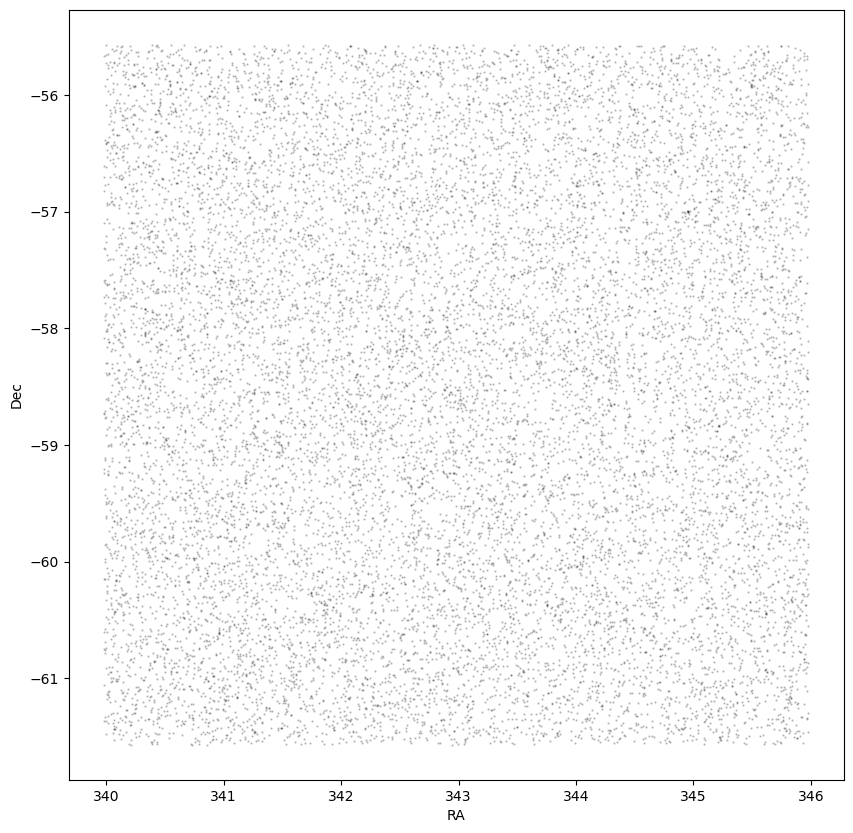

In [23]:

plt.figure(figsize=(10,10))

plt.scatter(r['ra'], r['dec'], s=.5, alpha=.2, c='k', rasterized=True)
plt.xlabel('RA')
plt.ylabel('Dec')
r['ra'].shape

## Playing with other cuts

In [14]:
### square select

##Reduce the amount of features we get

center_ra, center_dec = dwarfs['RAdeg'][fornaxid], dwarfs['DEdeg'][fornaxid]
degsep = 3 # Up to you? Might depend on the type of objects and crowdedness 
minmag = 20 # Maybe this should be modified?

## I have to retrieve in my note the additional cuts we might want to apply

## The cut in pmra/pmdec follow the wavelet paper; I don't know if we want to do it
## The cut in parallax - parallax_error is also following the wavelet paper and says it's to remove foreground stars but 
## I'd be in favor of asknig around the best way to do that? Or we keep it consistent with them like that

query = "SELECT ra, dec, pmra, pmdec, phot_g_mean_mag, parallax FROM gaiadr3.gaia_source \
WHERE (ra < {} \
AND ra > {} \
AND dec <  {} \
AND dec > {} \
AND pmra < 5 \
AND pmra > -5 \
AND pmdec > -5 \
AND pmdec < 5 \
AND phot_g_mean_mag < {} \
AND parallax IS NOT NULL \
AND parallax < 1 \
AND parallax_over_error > 1 \
AND ruwe < 1.4 \
AND ebpminrp_gspphot IS NOT NULL)".format(center_ra + degsep, center_ra - degsep, center_dec + degsep, center_dec - degsep,
                                         minmag)

print(query)
t= time.time()
job = Gaia.launch_job_async(query)

r = job.get_results()
print(time.time()-t)
print(len(r))

SELECT ra, dec, pmra, pmdec, phot_g_mean_mag, parallax FROM gaiadr3.gaia_source WHERE (ra < 103.4065 AND ra > 97.4065 AND dec <  -47.9593 AND dec > -53.9593 AND pmra < 5 AND pmra > -5 AND pmdec > -5 AND pmdec < 5 AND phot_g_mean_mag < 20 AND parallax IS NOT NULL AND parallax < 1 AND parallax_over_error > 1 AND ruwe < 1.4 AND ebpminrp_gspphot IS NOT NULL)
INFO: Query finished. [astroquery.utils.tap.core]
5.8136372566223145
42876


Text(0, 0.5, 'Dec')

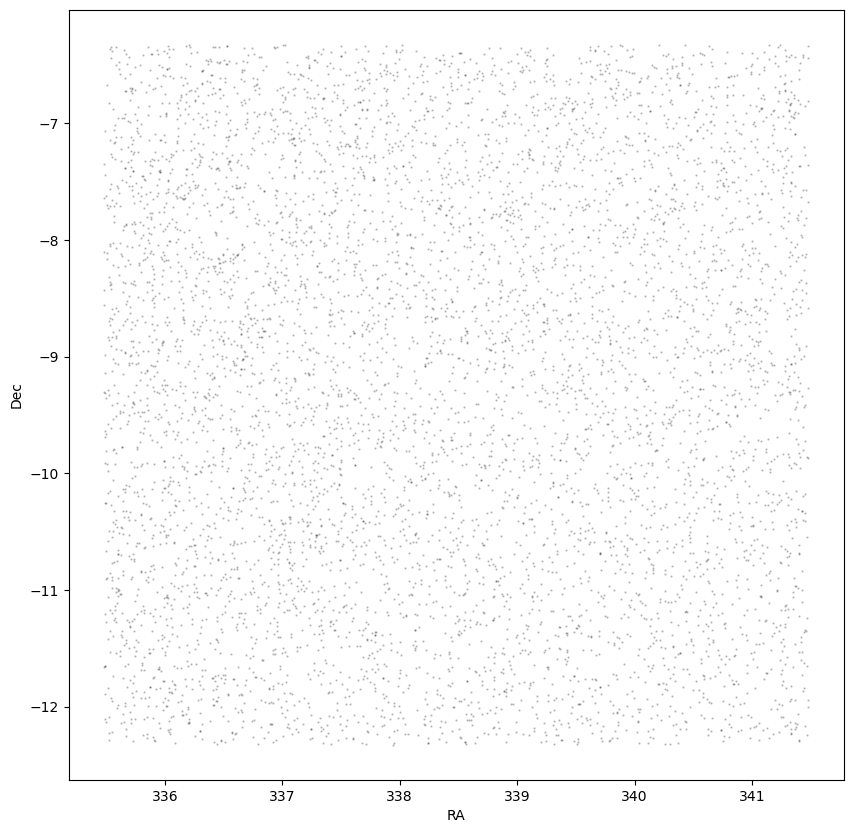

In [8]:

plt.figure(figsize=(10,10))

plt.scatter(r['ra'], r['dec'], s=.5, alpha=.2, c='k', rasterized=True)
plt.xlabel('RA')
plt.ylabel('Dec')

In [ ]:
# query = "SELECT ra, dec, pmra, pmdec, phot_g_mean_mag, parallax FROM gaiadr3.gaia_source \
# WHERE (ra < {} \
# AND ra > {} \
# AND dec <  {} \
# AND dec > {} \
# AND phot_g_mean_mag < {} \
# AND parallax IS NOT NULL \
# AND parallax_over_error > 10.0  \
# AND ruwe < 1.4 \
# AND ebpminrp_gspphot IS NOT NULL)

In [ ]:
from astroquery.vizier import Vizier
from astropy.coordinates import SkyCoord



In [ ]:
# Search for catalogs mentioning your dwarf galaxy
v = Vizier(columns=['**'], row_limit=-1)
catalogs = Vizier.find_catalogs('Carina gaia')

catalogs

OrderedDict([('I/324', </>),
             ('I/337', </>),
             ('I/345', </>),
             ('I/347', </>),
             ('I/350', </>),
             ('I/352', </>),
             ('I/355', </>),
             ('I/356', </>),
             ('I/357', </>),
             ('I/358', </>),
             ('I/359', </>),
             ('I/360', </>),
             ('I/361', </>),
             ('IV/36', </>),
             ('VI/137', </>),
             ('VI/145', </>),
             ('J/A+A/523/A48', </>),
             ('J/A+A/674/A25', </>)])

In [ ]:
# Once you identify the right catalog ID (e.g., 'J/ApJ/...')
result = v.get_catalogs(catalogs)
result

In [ ]:
result[0]

recno,HJD,Weight,RV(A),RV(B),res(A),res(B)
,d,,km / s,km / s,km / s,km / s
int32,float64,float32,float32,float32,float32,float32
1,2451144.83060,1.0,257.4,-279.8,-3.0,-2.0
2,2451145.84399,0.0,25.0,13.2,28.5,8.8
3,2451146.86755,1.0,-256.0,284.5,5.2,4.5
4,2451147.86649,0.0,-1.4,48.9,34.9,9.4
5,2451148.80902,1.0,247.7,-278.5,12.1,-1.4
6,2451149.87170,0.0,106.7,66.2,55.4,120.4
7,2451150.83746,1.0,-262.2,276.5,0.5,-5.1
8,2451152.73657,1.0,240.0,-275.1,-2.8,-16.1


In [ ]:
### Other option is a cone search but somehow it is super slow in some instances? 

# center_ra, center_dec = 76.16, -15.36
# degsep = 3

# ## This selects ALL features from gaia lite which is overkill
# query = "SELECT *,  DISTANCE( \
#    POINT({}, {}), \
#    POINT(ra, dec)) AS ang_sep \
# FROM gaiadr3.gaia_source_lite \
# WHERE 1 = CONTAINS( \
#    POINT({}, {}), \
#    CIRCLE(ra, dec, {})) \
# AND phot_g_mean_mag < 20 \
# AND parallax IS NOT NULL \
# AND parallax_over_error > 10.0  \
# AND ruwe < 1.4 \
# AND ebpminrp_gspphot IS NOT NULL".format(center_ra, center_dec, center_ra, center_dec, degsep)
# print(query)

# t= time.time()
# job = Gaia.launch_job_async(query)

# r = job.get_results()
# print(time.time()-t)

# Analysis

In [6]:
module_path = '/data/ascaffid/LHC_Olympics/EagleEye/eagleeye'
import sys
sys.path.append(module_path)
import EagleEye
from utils_EE import compute_the_null, partitioning_function
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
import random

import pandas as pd

import astropy
import astropy.table as at

from astropy.io import ascii
from astropy.table import Table

import matplotlib.cm as cm


from astropy.io.votable import parse, parse_single_table

from astropy.coordinates import SkyCoord
from dustmaps.planck import PlanckQuery
from dustmaps.sfd import SFDQuery
import astropy.units as units
import sklearn

import time
from astroquery.gaia import Gaia


SELECT source_id, ra, dec, pmra, pmdec, phot_g_mean_mag, parallax, parallax_error, ruwe
FROM gaiadr3.gaia_source
WHERE
  (ra BETWEEN 74.1691121 AND 78.1691121)
  AND (dec BETWEEN -17.29554739 AND -13.29554739)
  AND pmra BETWEEN -5 AND 5
  AND pmdec BETWEEN -5 AND 5
  AND (parallax - 3*parallax_error) < 0.0

INFO: Query finished. [astroquery.utils.tap.core]
4.840502500534058
30058


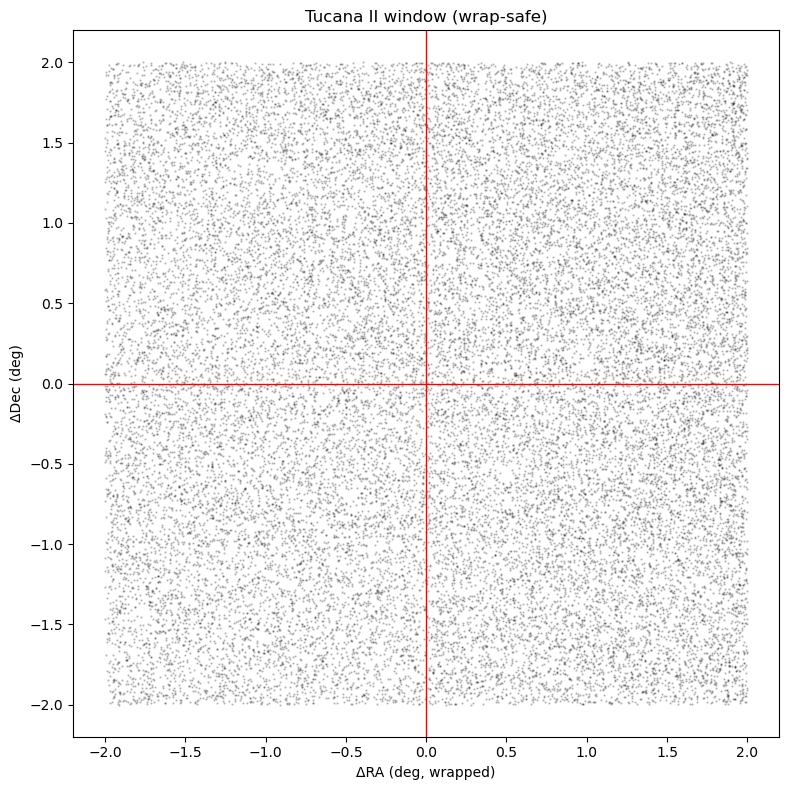

<class 'dict'>
{'med': array([0.02095165, 0.00775554, 1.16021229, 0.03804513]), 'mad': array([0.32097245, 0.33546967, 1.21664893, 1.39319745])}
Y shape: (3252, 4)
X_refs shapes: [(2961, 4), (3078, 4), (3657, 4), (2967, 4), (3833, 4), (3047, 4), (3464, 4), (3799, 4)]
Scaling med: [0.02095165 0.00775554 1.16021229 0.03804513]
Scaling mad: [0.32097245 0.33546967 1.21664893 1.39319745]


In [7]:

# RAN THESE DOWNLOADS SEPERATLY
# !wget https://www.cadc-ccda.hia-iha.nrc-cnrc.gc.ca/files/vault/PANDAS/NearbyGals/NearbyGalaxies_Jan2021_PUBLIC.fits
# !wget https://raw.githubusercontent.com/dwarfswaves/dwarfswaves.github.io/refs/heads/main/candidate_1.csv


candi_wavelet = pd.read_csv('candidate_2.csv')
candi_wavelet

nearby = at.Table.read('/data/ascaffid/Dwarfs/gaia_ee/NearbyGalaxies_Jan2021_PUBLIC.fits')
nearby

# https://iopscience.iop.org/article/10.3847/1538-4357/ab7eb9 
# Confirmed and candidates:
# (Classifications are: (1) unconfirmed systems, (2) probable star clusters, (3) probable dwarfs, (4) kinematically confirmed dwarfs)
# !wget https://content.cld.iop.org/journals/0004-637X/893/1/47/revision1/apjab7eb9t2_mrt.txt 
# this paper " recovered 18 out of 21 confirmed and candidate satellite galaxies in the DES footprint ; [..]
# recovered 20 of the 32 confirmed and candidate satellite galaxies known to reside in the PS1 DR1 footprint. 
# The lower recovery rate in PS1 is expected since many of the satellites in the PS1 footprint were discovered with significantly 
# deeper data. "

dwarfs =ascii.read('apjab7eb9t2_mrt.txt')


# Look at a dwarf
# dwarf_name = 'Bootes I'
# dwarf_name = 'Carina'
# dwarf_name = 'Tucana II'

# fornaxid = np.where(dwarfs['Name']==dwarf_name)[0][0]
# dwarfs[fornaxid]

### square select

##Reduce the amount of features we get
def ra_condition(ra0, degsep):
    ra_min = (ra0 - degsep) % 360.0
    ra_max = (ra0 + degsep) % 360.0
    if ra_min <= ra_max:
        return f"(ra BETWEEN {ra_min} AND {ra_max})"
    else:
        # crosses 0
        return f"(ra >= {ra_min} OR ra <= {ra_max})"
## large parallax: closer
## We want smaller parallax but still good measurement ?


# center_ra, center_dec = dwarfs['RAdeg'][fornaxid], dwarfs['DEdeg'][fornaxid]

# # Candidate 1
center_ra, center_dec = 76.1691121, -15.29554739

degsep = 2 # Up to you? Might depend on the type of objects and crowdedness 
minmag = 10 # lets ignore this cut

## I have to retrieve in my note the additional cuts we might want to apply

## The cut in pmra/pmdec follow the wavelet paper; I don't know if we want to do it
## The cut in parallax - parallax_error is also following the wavelet paper and says it's to remove foreground stars but 
## I'd be in favor of asknig around the best way to do that? Or we keep it consistent with them like that

ra_cut  = ra_condition(center_ra, degsep)
dec_cut = f"(dec BETWEEN {center_dec - degsep} AND {center_dec + degsep})"

query = f"""
SELECT source_id, ra, dec, pmra, pmdec, phot_g_mean_mag, parallax, parallax_error, ruwe
FROM gaiadr3.gaia_source
WHERE
  {ra_cut}
  AND {dec_cut}
  AND pmra BETWEEN -5 AND 5
  AND pmdec BETWEEN -5 AND 5
  AND (parallax - 3*parallax_error) < 0.0
"""

print(query)
t= time.time()
job = Gaia.launch_job_async(query)

r = job.get_results()
print(time.time()-t)
print(len(r))


import numpy as np
import matplotlib.pyplot as plt

def wrap_dra_deg(ra, ra0):
    """RA difference in degrees, wrapped to [-180, 180)."""
    return (ra - ra0 + 180.0) % 360.0 - 180.0

ra  = np.asarray(r['ra'], float)
dec = np.asarray(r['dec'], float)

# Compute wrapped offset from dwarf center
dra  = wrap_dra_deg(ra, center_ra)
ddec = dec - center_dec

plt.figure(figsize=(8,8))
plt.scatter(dra, ddec, s=0.5, alpha=0.2, c='k', rasterized=True)

plt.axvline(0, color='red', linewidth=1)
plt.axhline(0, color='red', linewidth=1)

plt.xlabel("ΔRA (deg, wrapped)")
plt.ylabel("ΔDec (deg)")
plt.title(f"{dwarf_name} window (wrap-safe)")
plt.gca().set_aspect('equal')
plt.tight_layout()
plt.show()

# Build Y and X_refs from a Gaia window split into a 3×3 grid,
# using LOCAL (cell-centered) coordinates for each cell, then applying ONE shared scaling
# (positions + velocities) fit from the TEST cell, so everything is on the same scale.



import numpy as np

def wrap_dra_deg(ra, ra0):
    """RA difference in degrees, wrapped to [-180, 180)."""
    return (ra - ra0 + 180.0) % 360.0 - 180.0

def split_into_3x3(ra, dec, ra0, dec0, cell_halfwidth_deg):
    """
    Same as your version: returns indices for test cell (center) and 8 surrounding refs.
    """
    h = float(cell_halfwidth_deg)
    dra  = wrap_dra_deg(np.asarray(ra, float), ra0)
    ddec = np.asarray(dec, float) - dec0

    ix = np.floor((dra + 3*h) / (2*h)).astype(int)
    iy = np.floor((ddec + 3*h) / (2*h)).astype(int)

    inside = (ix >= 0) & (ix < 3) & (iy >= 0) & (iy < 3)
    cell_id = np.full(len(dra), -1, dtype=int)
    cell_id[inside] = iy[inside] * 3 + ix[inside]  # 0..8

    test_id = 4
    ref_ids = [0, 1, 2, 3, 5, 6, 7, 8]

    out = {
        "cell_id": cell_id,
        "inside": inside,
        "test_idx": np.where(cell_id == test_id)[0],
        "ref_idx_list": [np.where(cell_id == rid)[0] for rid in ref_ids],
        "ref_ids": ref_ids,
    }
    return out

def robust_fit_mad(Z, eps=1e-12):
    """Robust center/scale using median and MAD (per feature)."""
    med = np.median(Z, axis=0)
    mad = np.median(np.abs(Z - med), axis=0)
    mad = np.where(mad < eps, 1.0, mad)
    return med, mad

def robust_apply(Z, med, mad):
    return (Z - med) / mad

def build_features_local_center(r, idx, ra_c, dec_c):
    """
    4D features comparable to wavelet:
      [dra*cos(dec_c), ddec, pmra, pmdec]
    with dra wrapped and multiplied by cos(dec_c).
    """
    ra    = np.asarray(r["ra"][idx], dtype=float)
    dec   = np.asarray(r["dec"][idx], dtype=float)
    pmra  = np.asarray(r["pmra"][idx], dtype=float)
    pmdec = np.asarray(r["pmdec"][idx], dtype=float)

    # dra  = wrap_dra_deg(ra, ra_c) * np.cos(np.deg2rad(dec_c))
    dra = wrap_dra_deg(ra, ra_c) * np.cos(np.deg2rad(dec0))  # constant across tiles
    ddec = dec - dec_c

    return np.column_stack([dra, ddec, pmra, pmdec]).astype(float)

def cell_center_from_id(ra0, dec0, cell_id, cell_halfwidth_deg):
    """
    Return (ra_center, dec_center) for a given 3×3 cell_id in {0..8},
    assuming global grid center is (ra0, dec0) and each cell has halfwidth h.

    Cell width = 2h.
    ix,iy in {0,1,2}; center offsets are (-2h, 0, +2h).
    """
    h = float(cell_halfwidth_deg)
    iy = cell_id // 3
    ix = cell_id % 3
    off = np.array([-2*h, 0.0, 2*h])
    ra_c  = ra0  + off[ix]
    dec_c = dec0 + off[iy]
    return ra_c, dec_c

def make_Xrefs_and_Y_from_window_3x3(
    r, ra0, dec0, cell_halfwidth_deg,
    fit_scaling_on="test",   # "test" recommended; alternatives: "all"
    do_robust_scale=True,
):
    """
    Returns:
      Y      : (nY,4) scaled features for test cell
      X_refs : list of 8 arrays, each (nXj,4) scaled features for ref cell j
      parts  : dict with indices + cell ids
      scale  : dict with med,mad used (or None if no scaling)
    """
    ra = np.asarray(r["ra"], float)
    dec = np.asarray(r["dec"], float)

    parts = split_into_3x3(ra, dec, ra0, dec0, cell_halfwidth_deg)
    test_idx = parts["test_idx"]
    ref_idx_list = parts["ref_idx_list"]
    ref_ids = parts["ref_ids"]

    # --- Build Y in local coords centered on TEST cell center (ra0,dec0) ---
    Y_raw = build_features_local_center(r, test_idx, ra0, dec0)

    # --- Build each reference in its OWN local coords centered on its own cell center ---
    X_refs_raw = []
    for rid, idx in zip(ref_ids, ref_idx_list):
        ra_c, dec_c = cell_center_from_id(ra0, dec0, rid, cell_halfwidth_deg)
        X_refs_raw.append(build_features_local_center(r, idx, ra_c, dec_c))

    # --- Fit scaling (positions + velocities) so refs are on the SAME scale as the test ---
    scale = {"med": None, "mad": None}
    if do_robust_scale:
        if fit_scaling_on == "test":
            Z_fit = Y_raw
        elif fit_scaling_on == "all":
            Z_fit = np.vstack([Y_raw] + X_refs_raw)
        else:
            raise ValueError("fit_scaling_on must be 'test' or 'all'.")

        med, mad = robust_fit_mad(Z_fit)
        scale = {"med": med, "mad": mad}

        Y = robust_apply(Y_raw, med, mad)
        X_refs = [robust_apply(Xj, med, mad) for Xj in X_refs_raw]
    else:
        Y = Y_raw
        X_refs = X_refs_raw

    return Y, X_refs, parts, scale


# -----------------------
# Example usage
# -----------------------
ra0, dec0 = center_ra, center_dec
cell_halfwidth_deg = degsep / 3.0   # so the center cell is your old ROI

Y, X_refs, parts, scale = make_Xrefs_and_Y_from_window_3x3(
    r, ra0, dec0, cell_halfwidth_deg,
    fit_scaling_on="all",
    do_robust_scale=True,
)

print(type(scale))
print(scale)

print("Y shape:", Y.shape)
print("X_refs shapes:", [Xj.shape for Xj in X_refs])
print("Scaling med:", scale["med"])
print("Scaling mad:", scale["mad"])

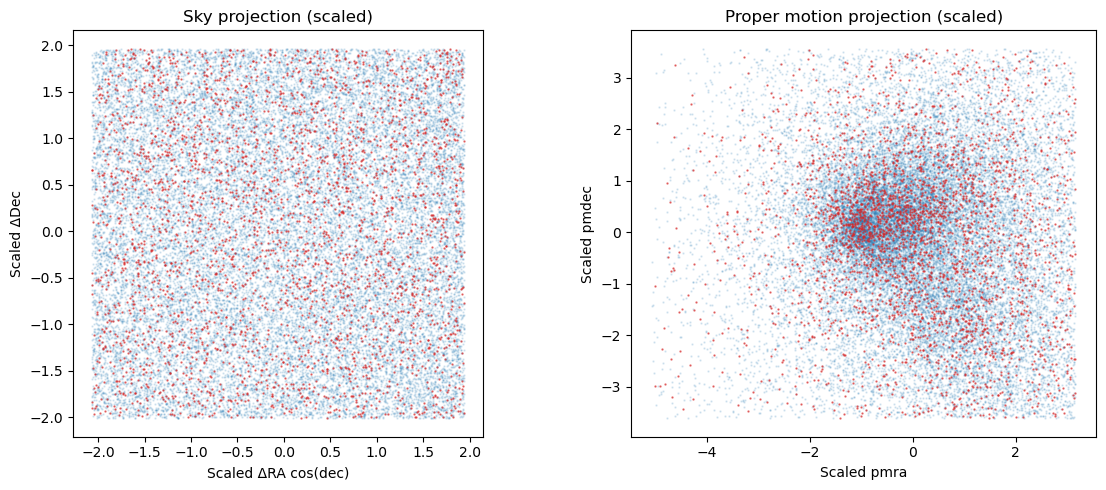

In [8]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# =========================
# SKY PROJECTION
# =========================
ax = axes[0]

# references
for Xj in X_refs:
    ax.scatter(Xj[:,0], Xj[:,1],
               s=0.5, alpha=0.15, color='tab:blue', rasterized=True)

# test
ax.scatter(Y[:,0], Y[:,1],
           s=0.5, alpha=0.6, color='tab:red', rasterized=True)

ax.set_xlabel("Scaled ΔRA cos(dec)")
ax.set_ylabel("Scaled ΔDec")
ax.set_title("Sky projection (scaled)")
ax.set_aspect('equal')

# =========================
# PROPER MOTION
# =========================
ax = axes[1]

for Xj in X_refs:
    ax.scatter(Xj[:,2], Xj[:,3],
               s=0.5, alpha=0.15, color='tab:blue', rasterized=True)

ax.scatter(Y[:,2], Y[:,3],
           s=0.5, alpha=0.6, color='tab:red', rasterized=True)

ax.set_xlabel("Scaled pmra")
ax.set_ylabel("Scaled pmdec")
ax.set_title("Proper motion projection (scaled)")
ax.set_aspect('equal')

plt.tight_layout()
plt.show()

## EagleEye

In [9]:
import numpy as np
from concurrent.futures import ProcessPoolExecutor, as_completed

def _compute_the_null_worker(args):
    """
    Top-level worker so it is picklable.
    """
    j, p_j, K_M, N = args
    from utils_EE import compute_the_null  # import inside worker for subprocess
    stats_null_j = compute_the_null(p=p_j, K_M=K_M, N=N)
    return j, float(p_j), stats_null_j


def compute_the_null_multi_refs(p_list, K_M, N=500_000, n_jobs=8):
    """
    Parallel multi-reference wrapper around utils_EE.compute_the_null.

    Parameters
    ----------
    p_list : list[float]
        p_j = n_Y/(n_Y+n_Xj) per reference.
    K_M : int
    N : int
    n_jobs : int

    Returns
    -------
    stats_null_multi : dict
      {
        "p_list": [...],
        "K_M": K_M,
        "N": N,
        "by_ref": {
            j: {"p": p_j, "stats_null": {...}},
            ...
        }
      }
    """
    p_list = list(map(float, p_list))
    tasks = [(j, p_j, int(K_M), int(N)) for j, p_j in enumerate(p_list)]

    by_ref = {}
    max_workers = min(int(n_jobs), len(tasks)) if tasks else 1

    with ProcessPoolExecutor(max_workers=max_workers) as ex:
        futures = [ex.submit(_compute_the_null_worker, t) for t in tasks]
        for fut in as_completed(futures):
            j, p_j, stats_null_j = fut.result()
            by_ref[j] = {"p": p_j, "stats_null": stats_null_j}

    return {"p_list": p_list, "K_M": K_M, "N": N, "by_ref": by_ref}




In [ ]:
p_list = [len(Y) / (len(Y) + len(Xj)) for Xj in X_refs]
kM = 300 # Keep about 10% of size of ref ant test ~400 for candidate 1
p_ext = 1E-3

# stats_null_multi = compute_the_null_multi_refs(
#     p_list=p_list,
#     K_M=kM,
#     N=200000,
#     n_jobs=8
# )

# Save srtats null multi to pickle
# import pickle
# with open("stats_null_multi.pkl", "wb") as f:
#     pickle.dump(stats_null_multi, f)

# RERUN ABOVE I USING NEW KM
# Load stats null multi from pickle
import pickle
with open("stats_null_multi.pkl", "rb") as f:
    stats_null_multi = pickle.load(f)

In [11]:
upsilonsS = []
for j, p_j in enumerate(p_list):
    null_array_j = stats_null_multi["by_ref"][j]["stats_null"][p_j]
    
    Gamma_star_j = np.quantile(
        null_array_j,
        1 - p_ext,
        method="higher"
    )
    upsilonsS.append(Gamma_star_j)
    print(f"Reference {j}: Gamma_star_j = {Gamma_star_j}")


Reference 0: Gamma_star_j = 9.41477465276182
Reference 1: Gamma_star_j = 9.484231636568454
Reference 2: Gamma_star_j = 9.380466177322022
Reference 3: Gamma_star_j = 9.37289304011953
Reference 4: Gamma_star_j = 9.391929871886504
Reference 5: Gamma_star_j = 9.44354495819906
Reference 6: Gamma_star_j = 9.323470993923381
Reference 7: Gamma_star_j = 9.358034940038916


In [12]:
import numpy as np
import EagleEye
from utils_EE import partitioning_function
from EagleEye import S_rootB_estimate_Y_overdensities, B_estimate_Y_overdensities

def compute_Gamma_i_multi_ref_with_SrootB(
    X_refs, Y,
    stats_null_multi,
    K_M=500,
    p_ext=1e-5,
    n_jobs=8,
    Z=2.65,
    upsilon_key="Upsilon_i_Y",
):
    R = len(X_refs)
    nY = len(Y)

    Upsilon_by_ref = np.zeros((R, nY), float)
    result_dicts   = []
    EE_books       = []
    SrootB_by_ref  = []
    B_by_ref       = []   # <-- NEW

    for j, Xj in enumerate(X_refs):
        stats_null_j = stats_null_multi["by_ref"][j]["stats_null"]

        # 1) Soar
        rd, _ = EagleEye.Soar(
            Xj, Y,
            K_M=K_M,
            p_ext=p_ext,
            n_jobs=n_jobs,
            stats_null=stats_null_j,
            result_dict_in={},
            do_IDE=True
        )

        if upsilon_key not in rd:
            raise KeyError(f"Ref {j}: missing '{upsilon_key}'. Keys: {list(rd.keys())}")

        ups = np.asarray(rd[upsilon_key], float)
        if ups.shape != (nY,):
            raise ValueError(f"Ref {j}: {upsilon_key} shape {ups.shape}, expected {(nY,)}")

        Upsilon_by_ref[j] = ups
        result_dicts.append(rd)

        # 2) Cluster
        clusters = partitioning_function(Xj, Y, rd, p_ext=p_ext, Z=Z)

        # 3) Repechage
        EE_book = EagleEye.Repechage(Xj, Y, rd, clusters, p_ext=p_ext)
        EE_books.append(EE_book)

        # 4a) s/sqrt(B)
        srb = S_rootB_estimate_Y_overdensities(rd, EE_book)
        SrootB_by_ref.append(srb)

        # 4b) B-hat (your new function)
        bhat = B_estimate_Y_overdensities(rd, EE_book)
        B_by_ref.append(bhat)

        # ---- Print cluster sizes + s/sqrt(B) + B-hat ----
        over_clusters = EE_book.get("Y_OVER_clusters", {})
        if isinstance(over_clusters, dict) and len(over_clusters) > 0:
            print(f"[ref {j}] Y_OVER_clusters: {len(over_clusters)}")
            for cid in sorted(over_clusters.keys()):
                rep = np.asarray(over_clusters[cid].get("Repechaged", []), dtype=int)
                bg  = np.asarray(over_clusters[cid].get("Background", []), dtype=int)
                pr  = np.asarray(over_clusters[cid].get("Pruned", []), dtype=int)

                srootb_c = srb.get("s/root(B)", {}).get(cid, np.nan)
                Bhat_c   = bhat.get("B", {}).get(cid, np.nan)
                ups_min  = srb.get("Upsilon_alpha_plus", {}).get(cid, np.nan)

                print(
                    f"  cluster {cid}: "
                    f"|Rep|={rep.size:4d}, |Bg|={bg.size:4d}, |Pr|={pr.size:4d} "
                    f" -> B̂={Bhat_c:.2f}, s/√B={srootb_c:.3f}, min(Upsilon)={ups_min:.3f}"
                )
        else:
            print(f"[ref {j}] Y_OVER_clusters: 0")

        print(f"[ref {j}] Total: "
              f"B̂={bhat.get('B', {}).get('Total', np.nan):.2f}, "
              f"s/√B={srb.get('s/root(B)', {}).get('Total', np.nan):.3f}")

    Gamma_i = np.sum(Upsilon_by_ref, axis=0)

    return {
        "Gamma_i": Gamma_i,
        "Upsilon_by_ref": Upsilon_by_ref,
        "result_dicts": result_dicts,
        "EE_books": EE_books,
        "SrootB_by_ref": SrootB_by_ref,
        "B_by_ref": B_by_ref,          # <-- NEW
        "p_ext": p_ext,
        "K_M": K_M,
        "Z": Z,
        "upsilon_key": upsilon_key,
    }


# Example call
out = compute_Gamma_i_multi_ref_with_SrootB(
    X_refs=X_refs,
    Y=Y,
    stats_null_multi=stats_null_multi,
    K_M=kM,
    p_ext=p_ext,
    n_jobs=100,
    Z=2.65,
    upsilon_key="Upsilon_i_Y"
)

Gamma_i        = out["Gamma_i"]
B_by_ref       = out["B_by_ref"]
SrootB_by_ref  = out["SrootB_by_ref"]
EE_books       = out["EE_books"]
result_dicts   = out["result_dicts"]

-----------------------------------------------------------------
Eagle...Soar!
-----------------------------------------------------------------
Compute the nearest neighbours
KNN completed: 0.00 %
-----------------------------------------------------------------
Flagging of putative anomalous points
-----------------------------------------------------------------


<IPython.core.display.Math object>

'DONE!'

<IPython.core.display.Math object>

'DONE!'

...

'DONE!'

<IPython.core.display.Math object>

alpha = 1


'DONE!'

[ref 7] Y_OVER_clusters: 1
  cluster 0: |Rep|=   6, |Bg|=  12, |Pr|=   5  -> B̂=14.03, s/√B=-2.143, min(Upsilon)=9.766
[ref 7] Total: B̂=14.03, s/√B=-2.143


In [13]:
# Bootstrat emperical null
import numpy as np

def bootstrap_gamma_null_uniform(
    X_refs, Y,
    stats_null_multi,
    K_M=kM,
    p_ext=p_ext,
    n_jobs=100,
    upsilon_key="Upsilon_i_Y",
    n_boot=50,
    seed=0,
):
    """
    Bootstrap an empirical null for Gamma_i by rerunning your *exact* multi-ref pipeline
    on Uniform([0,1]^d) vs Uniform([0,1]^d), matching the cardinalities of your real data.

    For each bootstrap b:
      - Generate Yb ~ Unif([0,1]^d) with len(Y) points
      - Generate each Xb_j ~ Unif([0,1]^d) with len(X_refs[j]) points
      - Call compute_Gamma_i_multi_ref(...) using the *same* stats_null_multi
      - Store Gamma_i^(b)

    Returns
    -------
    Gamma_null : np.ndarray, shape (n_boot, len(Y))
        Empirical null draws of the full pointwise Gamma_i vector.
    """
    rng = np.random.default_rng(seed)

    n_refs = len(X_refs)
    nY = len(Y)
    d = Y.shape[1]

    nX_list = [Xj.shape[0] for Xj in X_refs]

    Gamma_null = np.zeros((n_boot, nY), dtype=float)

    for b in range(n_boot):
        # generate null data with same cardinalities and same feature dimension
        Yb = rng.random((nY, d)).astype(float)
        Xb_refs = [rng.random((nX, d)).astype(float) for nX in nX_list]

        Gamma_b = compute_Gamma_i_multi_ref_with_SrootB(
            X_refs=Xb_refs,
            Y=Yb,
            stats_null_multi=stats_null_multi,
            K_M=K_M,
            p_ext=p_ext,
            n_jobs=n_jobs,
            upsilon_key=upsilon_key,
        )

        Gamma_null[b] = Gamma_b['Gamma_i']

        if (b + 1) % max(1, n_boot // 10) == 0:
            print(f"bootstrap {b+1}/{n_boot} done")

    return Gamma_null


def flatten_gamma_null(Gamma_null, finite_only=True):
    """
    Convenience: flatten bootstraps into one long 1D sample for quantiles/histograms.
    """
    g = Gamma_null.reshape(-1)
    if finite_only:
        g = g[np.isfinite(g)]
    return g


# -------------------------
# Example usage
# -------------------------
Gamma_null_mat = bootstrap_gamma_null_uniform(
    X_refs=X_refs, Y=Y,
    stats_null_multi=stats_null_multi,
    K_M=kM, p_ext=p_ext, n_jobs=100,
    upsilon_key="Upsilon_i_Y",
    n_boot=1,
    seed=42,
)



-----------------------------------------------------------------
Eagle...Soar!
-----------------------------------------------------------------
Compute the nearest neighbours
KNN completed: 0.00 %
-----------------------------------------------------------------
Flagging of putative anomalous points
-----------------------------------------------------------------


<IPython.core.display.Math object>

'DONE!'

<IPython.core.display.Math object>

'DONE!'

...

'DONE!'

<IPython.core.display.Math object>

alpha = 1


'DONE!'

[ref 7] Y_OVER_clusters: 1
  cluster 0: |Rep|=   4, |Bg|=  10, |Pr|=   5  -> B̂=nan, s/√B=nan, min(Upsilon)=nan
[ref 7] Total: B̂=11.68, s/√B=-2.247
bootstrap 1/1 done


In [14]:
import numpy as np
import numpy as np



def _pruned_dict_to_mask(pruned_dict, nY):
    mask = np.zeros(nY, dtype=bool)
    if pruned_dict is None:
        return mask

    if isinstance(pruned_dict, dict):
        if len(pruned_dict) == 0:
            return mask
        idxs = []
        for v in pruned_dict.values():
            if v is None:
                continue
            idxs.extend(list(v))
        if len(idxs) == 0:
            return mask
        idxs = np.asarray(idxs, dtype=int)
        idxs = idxs[(idxs >= 0) & (idxs < nY)]
        mask[idxs] = True
        return mask

    idxs = np.asarray(list(pruned_dict), dtype=int)
    if idxs.size == 0:
        return mask
    idxs = idxs[(idxs >= 0) & (idxs < nY)]
    mask[idxs] = True
    return mask


def combine_multi_ref_pruning(
    result_dicts,
    nY,
    p_ext=1e-5,
    upsilon_key="Upsilon_i_Y",
    pruned_key="Y_Pruned",
    ide_key="Y_IDE",
    # --- NEW: persistence definition ---
    persistence_mode="tilde_nonzero",   # "tilde_nonzero" | "survive_mask" | "tilde_above_ustar"
    treat_pruned_as_removed=True,
):
    """
    Combine multi-reference results after per-reference IDE/pruning has already run.

    Computes:
      - Gamma_raw: sum_j Upsilon_i^(j)
      - Gamma_tilde (aka Gamma_pruned): sum_j Upsilon_i^(j) * S_i^(j)  where S is survival
      - persistence: by default counts refs contributing nonzero to Gamma_tilde

    persistence_mode options
    ------------------------
    "tilde_nonzero":
        persistence_i = #{j : Upsilon_i^(j) * S_i^(j) > 0}
        (this is the most literal "persistence by surviving tilde gamma")

    "survive_mask":
        persistence_i = #{j : S_i^(j) == 1}
        (counts refs where i was not pruned, regardless of score magnitude)

    "tilde_above_ustar":
        persistence_i = #{j : Upsilon_i^(j) * S_i^(j) > Ustar_j}
        (counts refs where i remains significant after pruning)
    """
    R = len(result_dicts)
    Upsilon_by_ref = np.zeros((R, nY), dtype=float)
    pruned_masks = np.zeros((R, nY), dtype=bool)
    Ustar_by_ref = np.full(R, np.nan, dtype=float)

    # --- ingest per-ref arrays and pruning info ---
    for j, rd in enumerate(result_dicts):
        if upsilon_key not in rd:
            raise KeyError(f"Ref {j}: missing '{upsilon_key}'. Keys: {list(rd.keys())}")

        ups = np.asarray(rd[upsilon_key], dtype=float)
        if ups.shape[0] != nY:
            raise ValueError(f"Ref {j}: {upsilon_key} has shape {ups.shape}, expected ({nY},)")

        Upsilon_by_ref[j] = ups

        if "Upsilon_star_plus" in rd and isinstance(rd["Upsilon_star_plus"], dict) and p_ext in rd["Upsilon_star_plus"]:
            Ustar_by_ref[j] = float(rd["Upsilon_star_plus"][p_ext])

        pruned_obj = rd.get(pruned_key, None)
        if pruned_obj is None or (isinstance(pruned_obj, dict) and len(pruned_obj) == 0):
            pruned_obj = rd.get(ide_key, None)

        pruned_masks[j] = _pruned_dict_to_mask(pruned_obj, nY)

    survive_mask = pruned_masks

    # --- raw and tilde gammas ---
    Gamma_raw = Upsilon_by_ref.sum(axis=0)

    if treat_pruned_as_removed:
        Upsilon_tilde_by_ref = Upsilon_by_ref * survive_mask
        Gamma_tilde = Upsilon_tilde_by_ref.sum(axis=0)
    else:
        Upsilon_tilde_by_ref = Upsilon_by_ref.copy()
        Gamma_tilde = Gamma_raw.copy()

    # --- persistence definitions ---
    if persistence_mode == "tilde_nonzero":
        persistence = (Upsilon_tilde_by_ref > 0).sum(axis=0)

    elif persistence_mode == "survive_mask":
        persistence = survive_mask.sum(axis=0)

    elif persistence_mode == "tilde_above_ustar":
        if np.any(np.isnan(Ustar_by_ref)):
            raise ValueError("tilde_above_ustar requires Upsilon_star_plus[p_ext] for every ref.")
        persistence = (Upsilon_tilde_by_ref > Ustar_by_ref[:, None]).sum(axis=0)

    else:
        raise ValueError("persistence_mode must be one of: tilde_nonzero, survive_mask, tilde_above_ustar")

    return {
        "Gamma_raw": Gamma_raw,
        "Gamma_pruned": Gamma_tilde,              # kept name for compatibility
        "Gamma_tilde": Gamma_tilde,               # explicit alias
        "Upsilon_by_ref": Upsilon_by_ref,
        "Upsilon_tilde_by_ref": Upsilon_tilde_by_ref,
        "survive_mask": survive_mask,
        "persistence": persistence,
        "pruned_masks": pruned_masks,
        "Ustar_by_ref": Ustar_by_ref,
        "p_ext": p_ext,
        "upsilon_key": upsilon_key,
        "pruned_key_used": pruned_key,
        "persistence_mode": persistence_mode,
    }

# -------------------------
# Example usage
# -------------------------
nY = len(Y)
out = combine_multi_ref_pruning(result_dicts, nY=nY, p_ext=p_ext,persistence_mode='tilde_nonzero')
Gamma_i_raw    = out["Gamma_raw"]
Gamma_i_pruned = out["Gamma_pruned"]
persistence    = out["persistence"]
#
# # e.g. require survival in >= 5/8 references:
idx_persist = np.where(persistence >= 1)[0]
# Gamma_i_pruned = Gamma_i_pruned[idx_persist]

Empirical Gamma*: 49.44232116015245


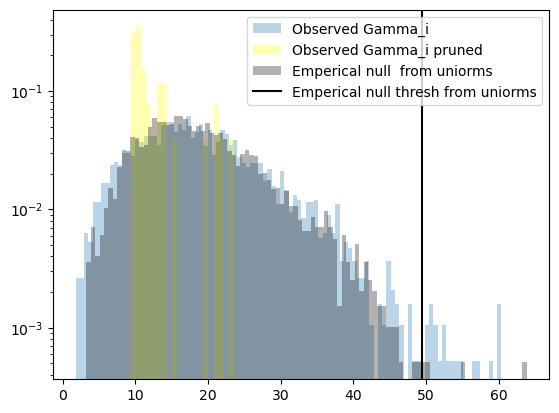

In [15]:
plist = stats_null_multi['p_list']
Gamma_null = np.sum(
    [
        stats_null_multi['by_ref'][ref_num]['stats_null'][p]
        for ref_num, p in enumerate(plist)
    ],
    axis=0
)


import numpy as np

def empirical_null_sum_gamma(stats_null_multi, plist, N_gamma=2_000_000, rng=None):
    """
    Empirical null for Gamma = sum_j Upsilon^(j), built by resampling from each ref's null.
    """
    if rng is None:
        rng = np.random.default_rng()

    # pull null arrays (1D) for each reference
    null_arrays = [
        np.asarray(stats_null_multi['by_ref'][j]['stats_null'][p], dtype=float)
        for j, p in enumerate(plist)
    ]

    Gamma_null = np.zeros(N_gamma, dtype=float)

    for arr in null_arrays:
        idx = rng.integers(0, arr.size, size=N_gamma)
        Gamma_null += arr[idx]

    return Gamma_null


import numpy as np

def p_to_upsilon(pvals, eps=1e-300):
    pvals = np.asarray(pvals, float)
    pvals = np.clip(pvals, eps, 1.0)
    return -np.log10(pvals)   # change if your Upsilon uses a different transform

def gamma_null_from_binomial_theory(stats_null_multi, plist, N_gamma=2_000_000, seed=0):
    rng = np.random.default_rng(seed)

    ups_null_arrays = []
    for j, p_j in enumerate(plist):
        null_p = np.asarray(stats_null_multi["by_ref"][j]["stats_null"][p_j], float)
        ups_null_arrays.append(null_p)

    Gamma_null = np.zeros(N_gamma, float)
    for ups in ups_null_arrays:
        idx = rng.integers(0, len(ups), size=N_gamma)
        Gamma_null += ups[idx]

    return Gamma_null


# Gamma_null = gamma_null_from_multi_refs_no_replacement(
#     stats_null_multi=stats_null_multi,
#     plist=plist,
#     N=50000,      # must be <= min len among refs' null arrays
#     which="plus",
#     seed=42
# )

# plt.yscale('log')
# --- 1) Combined null (Gamma_null) ---
# plt.hist(
#     Gamma_null,
#     bins=200,
#     density=True,
#     histtype='step',
#     linewidth=2,
#     label='Gamma null (sum)'
# )



# Gamma_null = empirical_null_sum_gamma(stats_null_multi, plist, N_gamma=2_000_000)
# # h=plt.hist(Gamma_i,bins=1000,density=True,alpha=0.3)
# plt.yscale('log')
# # --- 1) Combined null (Gamma_null) ---
# plt.hist(
#     Gamma_null,
#     bins=200,
#     density=True,
#     histtype='step',
#     linewidth=2,
#     label='Gamma null (empirical)'
# )




# Gamma_null_b_th = gamma_null_from_binomial_theory(stats_null_multi, plist, N_gamma=50000)
# # h=plt.hist(Gamma_i,bins=1000,density=True,alpha=0.3)
# plt.yscale('log')
# # --- 1) Combined null (Gamma_null) ---
# h = plt.hist(
#     Gamma_null_b_th,
#     bins=200,
#     density=True,
#     histtype='step',
#     linewidth=2,
#     label='Gamma null (From binomial th)'
# )


# # --- 2) Individual reference nulls ---
# for ref_num, p in enumerate(plist):
#     null_j = stats_null_multi['by_ref'][ref_num]['stats_null'][p]
#     plt.hist(
#         null_j,
#         bins=100,
#         density=True,
#         histtype='step',
#         alpha=0.4,
#         linewidth=1,
#         label=f'Null ref {ref_num}'
#     )

# --- 3) Observed Gamma_i ---
plt.hist(
    Gamma_i[np.isfinite(Gamma_i)],
    bins=100,
    density=True,
    alpha=0.3,
    label='Observed Gamma_i'
)


# # --- 3) Observed Gamma_i pruned ---
plt.hist(
    Gamma_i_pruned[idx_persist],
    bins=20,
    density=True,
    alpha=0.3,
    label='Observed Gamma_i pruned',color='yellow'
)




Gamma_null_1d = flatten_gamma_null(Gamma_null_mat)
alpha_pt = 1E-3 
Gamma_star_emp = np.quantile(Gamma_null_1d, 1 - alpha_pt)
print("Empirical Gamma*:", Gamma_star_emp)

# --- 3) Observed Gamma_i pruned ---
plt.hist(
    Gamma_null_1d,
    bins=100,
    density=True,
    alpha=0.3,
    label='Emperical null  from uniorms',color='k'
)


# plt.hist(
#     Gamma_null_1d_perm.ravel(),
#     bins=100,
#     density=True,
#     alpha=0.3,
#     label='Emperical null  perrms',
# )

# plt.hist(
#     M_perm.ravel(),
#     bins=100,
#     density=True,
#     alpha=0.3,
#     label='Emperical null  max perms ',
# )


# alpha_pt = 1e-4    # Bonferroni per-point level
# Gamma_star      = np.quantile(Gamma_null_b_th, 1 - alpha_pt)
# Gamma_star_emp =  np.quantile(Gamma_null, 1 - 1E-5)

gamma_sum_star = sum(upsilonsS)
# plt.axvline(x=Gamma_star,color='k',alpha=0.5)
# plt.axvline(Gamma_star,color='r')
plt.axvline(Gamma_star_emp,color='k',label='Emperical null thresh from uniorms')
# plt.axvline(Gamma_star_pointwise,color='r',label='Emperical null thresh from perms')

plt.legend()

plt.yscale('log')
# plt.xlim([0,200])

N persistent: 20 out of 3252


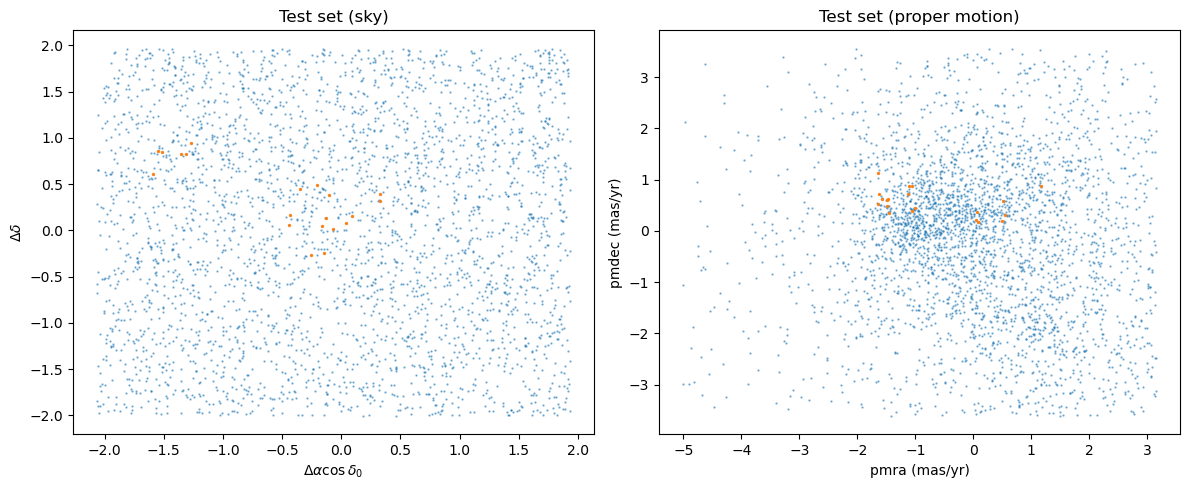

In [16]:
import numpy as np
import matplotlib.pyplot as plt

# --- build mask from persistence indices ---
mask_finite = np.isfinite(Gamma_i)

pass_thr = np.zeros(len(Y), dtype=bool)
# pass_thr[idx_persist] = True   # <-- use persistence indices
# pass_thr[Gamma_i<Gamma_star_emp] = False

pass_thr[Gamma_i>Gamma_star_emp] = True

print("N persistent:", sum(pass_thr), "out of", len(Y))

# --- features ---
x, y = Y[:, 0], Y[:, 1]      # sky-projected coords
u, v = Y[:, 2], Y[:, 3]      # pmra, pmdec

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# =====================
# Panel A: sky
# =====================
axes[0].scatter(x[mask_finite], y[mask_finite],
                s=0.5, alpha=0.5, rasterized=True)

axes[0].scatter(x[pass_thr], y[pass_thr],
                s=2.0, alpha=0.9, rasterized=True)

axes[0].set_xlabel(r'$\Delta\alpha\cos\delta_0$')
axes[0].set_ylabel(r'$\Delta\delta$')
axes[0].set_title('Test set (sky)')

# =====================
# Panel B: proper motion
# =====================
axes[1].scatter(u[mask_finite], v[mask_finite],
                s=0.5, alpha=0.5, rasterized=True)

axes[1].scatter(u[pass_thr], v[pass_thr],
                s=2.0, alpha=0.9, rasterized=True)

axes[1].set_xlabel(r'pmra (mas/yr)')
axes[1].set_ylabel(r'pmdec (mas/yr)')
axes[1].set_title('Test set (proper motion)')

plt.tight_layout()
plt.show()

### Average Z-score

In [17]:
import numpy as np

def persist_significance_overlap_with_Gamma(
    EE_books,
    SrootB_by_ref,
    Gamma_pass_mask,
    overlap_min=1,
    use_cluster_key="Repechaged",
    verbose=True,
):

    A_Gamma_mask = np.asarray(Gamma_pass_mask, dtype=bool)
    nY = A_Gamma_mask.size
    A_Gamma_idx = np.where(A_Gamma_mask)[0]

    R = len(EE_books)

    Lambda_sum = np.zeros(nY, dtype=float)
    J_count    = np.zeros(nY, dtype=int)
    Y_persist_mask = np.zeros(nY, dtype=bool)

    support_by_ref = []

    for j in range(R):
        EE_book = EE_books[j]
        srb     = SrootB_by_ref[j]
        z_by_cluster = srb.get("s/root(B)", {})

        over_clusters = EE_book.get("Y_OVER_clusters", {})
        if not isinstance(over_clusters, dict) or len(over_clusters) == 0:
            support_by_ref.append({"ref": j, "supporting_clusters": []})
            continue

        supporting = []

        for cid in sorted(over_clusters.keys()):
            cdict = over_clusters[cid]

            if use_cluster_key == "Repechaged":
                members = np.asarray(cdict.get("Repechaged", []), dtype=int)
            elif use_cluster_key == "Repechaged+Pruned":
                members = np.unique(np.concatenate([
                    np.asarray(cdict.get("Repechaged", []), dtype=int),
                    np.asarray(cdict.get("Pruned", []), dtype=int),
                ]))
            else:
                raise ValueError("Unsupported cluster key option")

            if members.size == 0:
                continue

            overlap = np.intersect1d(members, A_Gamma_idx, assume_unique=False)
            overlap_size = overlap.size

            if overlap_size < overlap_min:
                continue

            overlap_fraction = overlap_size / members.size

            # get cluster z-score
            lam = z_by_cluster.get(cid, np.nan)
            try:
                lam = float(lam)
            except Exception:
                lam = np.nan

            # ---- NEW: ignore clusters with z <= 0 ----
            if not np.isfinite(lam) or lam <= 0:
                continue

            supporting.append({
                "cluster_id": cid,
                "Lambda": lam,
                "size_members": int(members.size),
                "size_overlap": int(overlap_size),
                "overlap_fraction": float(overlap_fraction),
            })

            # update persistent region
            Y_persist_mask[members] = True

            # update per-point Lambda
            Lambda_sum[members] += lam
            J_count[members]    += 1

        support_by_ref.append({"ref": j, "supporting_clusters": supporting})

        if verbose:
            if len(supporting) == 0:
                print(f"[ref {j}] no supporting clusters")
            else:
                print(f"[ref {j}] supporting clusters: {len(supporting)}")
                for s in supporting:
                    print(
                        f"  cid={s['cluster_id']}: "
                        f"|members|={s['size_members']}, "
                        f"|overlap|={s['size_overlap']}, "
                        f"overlap_frac={s['overlap_fraction']:.3f}, "
                        f"Lambda={s['Lambda']:.3f}"
                    )

    Lambda_bar = np.full(nY, np.nan)
    flagged = J_count > 0
    Lambda_bar[flagged] = Lambda_sum[flagged] / J_count[flagged]

    Y_persist_idx = np.where(Y_persist_mask)[0]

    persist_scored = Y_persist_mask & np.isfinite(Lambda_bar)
    if np.any(persist_scored):
        Lambda_persist = float(np.mean(Lambda_bar[persist_scored]))
    else:
        Lambda_persist = np.nan

    if verbose:
        print(f"\nA_Gamma size: {A_Gamma_idx.size}")
        print(f"Y_persist size: {Y_persist_idx.size}")
        print(f"Lambda^Persist: {Lambda_persist:.4f}\n")

    return {
        "A_Gamma_idx": A_Gamma_idx,
        "Y_persist_idx": Y_persist_idx,
        "Lambda_bar": Lambda_bar,
        "J_count": J_count,
        "Lambda_persist": Lambda_persist,
        "support_by_ref": support_by_ref,
    }
# -------------------------
# Example usage (exactly as you described)
# -------------------------
# final Gamma anomaly mask:
# pass_thr is boolean mask of Y already (e.g. finite + other criteria)
A_Gamma_mask = pass_thr 

out_persist = persist_significance_overlap_with_Gamma(
    EE_books=EE_books,
    SrootB_by_ref=SrootB_by_ref,
    Gamma_pass_mask=A_Gamma_mask,
    overlap_min=1,               # or 2/3 to avoid 1-point accidental overlaps
    use_cluster_key="Repechaged",
    verbose=True,
)

print("Lambda^Persist =", out_persist["Lambda_persist"])

[ref 0] supporting clusters: 1
  cid=0: |members|=13, |overlap|=10, overlap_frac=0.769, Lambda=2.632
[ref 1] supporting clusters: 1
  cid=0: |members|=7, |overlap|=5, overlap_frac=0.714, Lambda=1.655
[ref 2] no supporting clusters
[ref 3] supporting clusters: 1
  cid=0: |members|=11, |overlap|=1, overlap_frac=0.091, Lambda=2.366
[ref 4] no supporting clusters
[ref 5] no supporting clusters
[ref 6] no supporting clusters
[ref 7] no supporting clusters

A_Gamma size: 20
Y_persist size: 31
Lambda^Persist: 2.3168

Lambda^Persist = 2.3167900702699784


Matched candidates by sky: 16 / 17
Worst sep (arcsec) among matched: 0.0012963235447066704

A_Gamma total size: 20
DBSCAN clusters (>=0): [0, 1]
DBSCAN noise points (ignored): 1

[Gamma cluster 0] S=   6  B̂=3.7820197044334973  s/√B=3.085242866099836
[Gamma cluster 1] S=  13  B̂=6.362068965517241  s/√B=5.153997054408973


/tmp/ipykernel_3792105/352605606.py:300: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap("tab10", max(1, len(labels)))


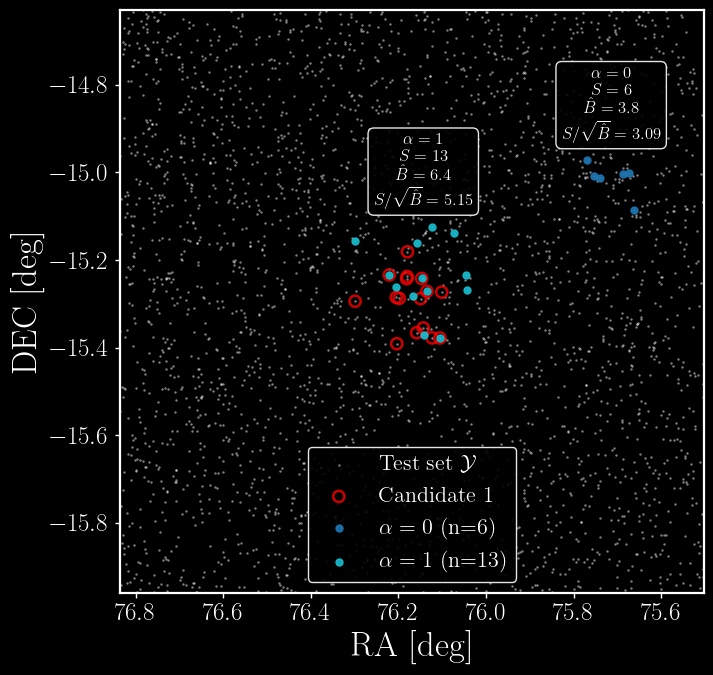

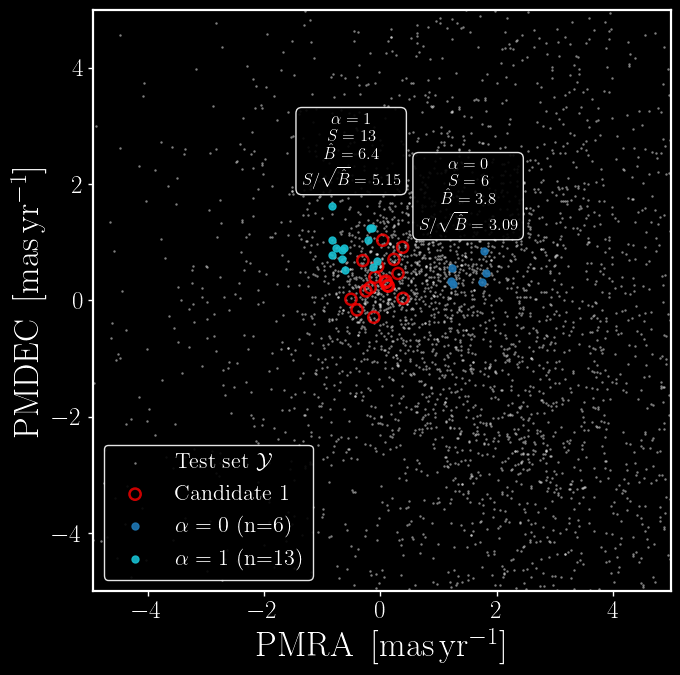

In [50]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

import numpy as np
from sklearn.cluster import DBSCAN

def cluster_A_Gamma_DBSCAN_no_noise(
    Y, A_Gamma_mask, eps=0.6, min_samples=5, use_cols=(0,1,2,3)
):
    """
    Cluster A_Gamma points using DBSCAN and DROP noise (-1).
    Returns:
      labels_all : (nY,) int, -2 outside A_Gamma, -1 for A_Gamma noise, >=0 cluster labels
      clusters   : dict {label>=0 : np.ndarray(indices)}
      noise_idx  : np.ndarray(indices)  (A_Gamma points labeled -1)
    """
    A_Gamma_mask = np.asarray(A_Gamma_mask, bool)
    nY = Y.shape[0]
    idx = np.where(A_Gamma_mask)[0]

    labels_all = np.full(nY, -2, dtype=int)  # -2 = not in A_Gamma
    if idx.size == 0:
        return labels_all, {}, np.array([], dtype=int)

    Z = np.asarray(Y[:, use_cols], float)
    lab = DBSCAN(eps=float(eps), min_samples=int(min_samples)).fit_predict(Z[idx])

    labels_all[idx] = lab
    noise_idx = idx[lab == -1]

    clusters = {}
    for k in np.unique(lab):
        if k == -1:
            continue
        clusters[int(k)] = idx[lab == k]

    return labels_all, clusters, noise_idx

import numpy as np

def srootB_for_Gamma_clusters_from_Brefs(
    EE_books,
    SrootB_by_ref,   # used only as filter: keep only EE clusters with z>0
    B_by_ref,        # your B_estimate_Y_overdensities outputs
    Y,
    A_Gamma_mask,
    overlap_min=1,
    use_cluster_key="Repechaged",
    weight_mode="overlap",      # "overlap" (default) or "n_support"
    dbscan_eps=0.6,
    dbscan_min_samples=5,
    cluster_cols=(0,1,2,3),
    verbose=True,
):
    """
    For each Gamma-cluster g (DBSCAN labels >= 0):
      S_g = |Gamma-cluster|
      B_g = weighted avg of Bhat(c,j) over (ref j, EE cluster c) with:
            - EE cluster intersects Gamma cluster (>= overlap_min points)
            - EE cluster z-score > 0
      s/sqrt(B)_g = (S_g - B_g)/sqrt(B_g)

    Returns dict with clusters, noise_idx, and per-cluster stats.
    """

    A_Gamma_mask = np.asarray(A_Gamma_mask, bool)
    nY = Y.shape[0]
    if A_Gamma_mask.size != nY:
        raise ValueError("A_Gamma_mask must have length len(Y)")

    labels_all, gamma_clusters, noise_idx = cluster_A_Gamma_DBSCAN_no_noise(
        Y, A_Gamma_mask, eps=dbscan_eps, min_samples=dbscan_min_samples, use_cols=cluster_cols
    )

    R = len(EE_books)
    if len(SrootB_by_ref) != R or len(B_by_ref) != R:
        raise ValueError("EE_books, SrootB_by_ref, B_by_ref must have same length")

    def _EE_members(cdict):
        if use_cluster_key == "Repechaged":
            return np.asarray(cdict.get("Repechaged", []), dtype=int)
        elif use_cluster_key == "Repechaged+Pruned":
            return np.unique(np.concatenate([
                np.asarray(cdict.get("Repechaged", []), dtype=int),
                np.asarray(cdict.get("Pruned", []), dtype=int),
            ]))
        else:
            raise ValueError("use_cluster_key must be 'Repechaged' or 'Repechaged+Pruned'")

    cluster_stats = {}

    if verbose:
        print(f"\nA_Gamma total size: {A_Gamma_mask.sum()}")
        print(f"DBSCAN clusters (>=0): {sorted(gamma_clusters.keys())}")
        print(f"DBSCAN noise points (ignored): {noise_idx.size}\n")

    for gid, A_idx in gamma_clusters.items():
        A_idx = np.asarray(A_idx, dtype=int)
        S = int(A_idx.size)

        B_num = 0.0
        W_num = 0.0
        contributors = []  # store (ref, cid, overlap, w, Bhat, z)

        for j in range(R):
            EE_book = EE_books[j]
            srb     = SrootB_by_ref[j]
            bhat    = B_by_ref[j]

            z_by_cluster = srb.get("s/root(B)", {})
            B_by_cluster = bhat.get("B", {})

            over_clusters = EE_book.get("Y_OVER_clusters", {})
            if not isinstance(over_clusters, dict) or len(over_clusters) == 0:
                continue

            for cid in sorted(over_clusters.keys()):
                members = _EE_members(over_clusters[cid])
                if members.size == 0:
                    continue

                ov = int(np.intersect1d(members, A_idx, assume_unique=False).size)
                if ov < int(overlap_min):
                    continue

                # filter: use only EE clusters with z>0
                z = z_by_cluster.get(cid, np.nan)
                try:
                    z = float(z)
                except Exception:
                    z = np.nan
                if not np.isfinite(z) or z <= 0:
                    continue

                Bc = B_by_cluster.get(cid, np.nan)
                try:
                    Bc = float(Bc)
                except Exception:
                    Bc = np.nan
                if not np.isfinite(Bc) or Bc <= 0:
                    continue

                if weight_mode == "overlap":
                    w = float(ov)
                elif weight_mode == "n_support":
                    w = 1.0
                else: 
                    raise ValueError("weight_mode must be 'overlap' or 'n_support'")

                B_num += w * Bc
                W_num += w
                contributors.append({"ref": j, "cid": int(cid), "overlap": ov, "w": w, "Bhat": Bc, "z": z})

        B_weighted = (B_num / W_num) if W_num > 0 else np.nan
        s_over_rootB = (S) / np.sqrt(B_weighted) if np.isfinite(B_weighted) and B_weighted > 0 else np.nan

        cluster_stats[int(gid)] = {
            "S": S,
            "B_weighted": B_weighted,
            "s_over_rootB": s_over_rootB,
            "contributors": contributors,
            "W_num": W_num,
            "A_idx": A_idx,
        }

        if verbose:
            print(f"[Gamma cluster {gid}] S={S:4d}  B̂={B_weighted}  s/√B={s_over_rootB}")

    return {
        "gamma_clusters": gamma_clusters,
        "noise_idx": noise_idx,
        "cluster_stats": cluster_stats,
        "labels_all": labels_all,
        "dbscan": {"eps": dbscan_eps, "min_samples": dbscan_min_samples, "cols": cluster_cols},
        "use_cluster_key": use_cluster_key,
        "weight_mode": weight_mode,
        "overlap_min": overlap_min,
    }


import numpy as np

import numpy as np

def get_Y_absolute_from_r(r, parts):
    """
    Returns absolute coordinates for each row in Y (test cell):
      raY, decY, pmraY, pmdecY : (nY,)
    Using parts["test_idx"] mapping from Y-row -> row in r.
    """
    test_idx = np.asarray(parts["test_idx"], dtype=int)

    raY    = np.asarray(r["ra"][test_idx], float)
    decY   = np.asarray(r["dec"][test_idx], float)
    pmraY  = np.asarray(r["pmra"][test_idx], float)
    pmdecY = np.asarray(r["pmdec"][test_idx], float)

    return raY, decY, pmraY, pmdecY
def candidate_to_scaled_features(cand_df, center_ra, center_dec, scale):
    """
    cand_df must have: ra_deg, dec_deg, pmra, pmdec  (in deg, deg, mas/yr, mas/yr)
    Returns:
      cand_scaled : (nCand, 4) in the same scaled space as Y
    """
    ra0  = float(center_ra)
    dec0 = float(center_dec)
    cos_dec0 = np.cos(np.deg2rad(dec0))

    ra  = cand_df["ra_deg"].to_numpy(float)
    dec = cand_df["dec_deg"].to_numpy(float)
    pmra  = cand_df["pmra"].to_numpy(float)
    pmdec = cand_df["pmdec"].to_numpy(float)

    # wrap ΔRA to [-180, 180)
    dra = (ra - ra0 + 180.0) % 360.0 - 180.0
    dra_cos = dra * cos_dec0
    ddec = dec - dec0

    cand_raw = np.column_stack([dra_cos, ddec, pmra, pmdec]).astype(float)

    med = np.asarray(scale["med"], float)
    mad = np.asarray(scale["mad"], float)
    cand_scaled = (cand_raw - med) / mad

    return cand_scaled

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# -----------------------------
# 0) Publication-style settings
# -----------------------------



# -------------------------------------------------------
# 1) Convert candidate table -> raw LOCAL features + scaled
# -------------------------------------------------------
def wrap_dra_deg(ra, ra0):
    return (ra - ra0 + 180.0) % 360.0 - 180.0

def candidate_to_raw_local_features(cand_df, center_ra, center_dec):
    """
    cand_df has: ra_deg, dec_deg, pmra, pmdec
    Returns cand_raw_local: (nCand,4) = [dra*cos(dec0), ddec, pmra, pmdec] in ORIGINAL UNITS.
    """
    ra0  = float(center_ra)
    dec0 = float(center_dec)
    cos_dec0 = np.cos(np.deg2rad(dec0))

    ra    = cand_df["ra_dr3"].to_numpy(float)
    dec   = cand_df["dec_dr3"].to_numpy(float)
    pmra  = cand_df["pmra_dr3"].to_numpy(float)
    pmdec = cand_df["pmdec_dr3"].to_numpy(float)

    dra  = wrap_dra_deg(ra, ra0)
    dra_cos = dra * cos_dec0
    ddec = dec - dec0

    return np.column_stack([dra_cos, ddec, pmra, pmdec]).astype(float)

def apply_robust_scale(Z_raw, scale):
    med = np.asarray(scale["med"], float)
    mad = np.asarray(scale["mad"], float)
    return (Z_raw - med) / mad

def invert_robust_scale(Z_scaled, scale):
    med = np.asarray(scale["med"], float)
    mad = np.asarray(scale["mad"], float)
    return Z_scaled * mad + med


# -------------------------------------------------------------------
# 2) Plot in RAW (unscaled) physical units, with LaTeX axis labels
# -------------------------------------------------------------------
import matplotlib.cm as cm
import numpy as np
import matplotlib.pyplot as plt

def plot_Gamma_clusters_abs_with_candidates(
    r,
    parts,
    gamma_clusters,         # dict: gid -> indices into Y (test-cell rows)
    cluster_stats,          # cluster_stats[gid]["s_over_rootB"], ["B_weighted"], ["S"]
    cand_df,                # DataFrame with ra_deg, dec_deg, pmra, pmdec
    figsize=(8, 7),
    alpha_bg=0.25,
    s_bg=3,
    s_cl=25,
    s_cand=65,
    title_sky=r"$\Gamma_\alpha$ clusters (sky)",
    title_pm=r"$\Gamma_\alpha$ clusters (proper motion)",
):
    # Absolute arrays aligned with Y rows:
    raY, decY, pmraY, pmdecY = get_Y_absolute_from_r(r, parts)

    labels = sorted(gamma_clusters.keys())
    cmap = cm.get_cmap("tab10", max(1, len(labels)))

    # ------------------------
    # SKY (RA/Dec)
    # ------------------------
    fig, ax = plt.subplots(figsize=figsize, facecolor="black")
    ax.set_facecolor("black")

    # Background: ALL test-cell points
    ax.scatter(
        raY, decY, s=s_bg, alpha=alpha_bg, color="white",
        rasterized=True, linewidths=0, label=r"Test set $\mathcal{Y}$"
    )

    # Candidate overlay (red, hollow)
    ax.scatter(
        cand_df["ra_dr3"].to_numpy(float),
        cand_df["dec_dr3"].to_numpy(float),
        s=s_cand, alpha=0.8, facecolors="none", edgecolors="red",
        linewidths=1.8, label=r"Candidate 1"
    )

    # Clusters
    for k, gid in enumerate(labels):
        pts = np.asarray(gamma_clusters[gid], dtype=int)
        if pts.size == 0:
            continue

        ax.scatter(
            raY[pts], decY[pts],
            s=s_cl, alpha=0.9, color=cmap(k),
            rasterized=True, label=rf"$\alpha={gid}$ (n={pts.size})"
        )

        # label box above cluster (in Dec)
        cx = float(np.mean(raY[pts]))
        y_top = float(np.max(decY[pts]))
        y_range = float(np.nanmax(decY) - np.nanmin(decY))
        box_y = y_top + 0.03 * y_range

        srb = cluster_stats[int(gid)]["s_over_rootB"]
        S   = cluster_stats[int(gid)]["S"]
        B   = cluster_stats[int(gid)]["B_weighted"]

        txt = (
            rf"$\alpha={gid}$" + "\n" +
            rf"$S={S}$" + "\n" +
            rf"$\hat{{B}}={B:.1f}$" + "\n" +
            rf"$S/\sqrt{{\hat{{B}}}}={srb:.2f}$"
        )
        ax.text(
            cx, box_y, txt,
            fontsize=12, ha="center", va="bottom",
            color='white',
            bbox=dict(
            boxstyle="round,pad=0.35",
            facecolor="black", edgecolor="white", alpha=0.90
            )
        )

    xmin, xmax = np.nanmin(raY), np.nanmax(raY)
    ymin, ymax = np.nanmin(decY), np.nanmax(decY)
    ax.margins(x=0, y=0)
    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)

    ax.set_xlabel(r"RA $\mathrm{[deg]}$", color="white", fontsize=25)
    ax.set_ylabel(r"DEC $\mathrm{[deg]}$", color="white", fontsize=25)
    ax.set_title(title_sky, color="white", fontsize=25)

    for spine in ax.spines.values():
        spine.set_color("white")
        spine.set_linewidth(1.6)

    ax.tick_params(colors="white", labelsize=18)
    ax.invert_xaxis()  # astronomy convention
    ax.set_aspect("equal", adjustable="box")

    leg = ax.legend(frameon=True, fancybox=True, framealpha=0.9, fontsize=16)
    leg.get_frame().set_facecolor("black")
    leg.get_frame().set_edgecolor("white")
    for txt in leg.get_texts():
        txt.set_color("white")

    plt.tight_layout()
    plt.savefig("Gamma_clusters_sky_candidate1.png", dpi=300, facecolor=fig.get_facecolor())
    plt.show()

    # ------------------------
    # Proper motion (pmra/pmdec)
    # ------------------------
    fig, ax = plt.subplots(figsize=figsize, facecolor="black")
    ax.set_facecolor("black")

    ax.scatter(
        pmraY, pmdecY, s=s_bg, alpha=alpha_bg, color="white",
        rasterized=True, linewidths=0, label=r"Test set $\mathcal{Y}$"
    )

    # Candidate overlay (red, hollow)
    ax.scatter(
        cand_df["pmra"].to_numpy(float),
        cand_df["pmdec"].to_numpy(float),
        s=s_cand, alpha=0.8, facecolors="none", edgecolors="red",
        linewidths=1.8, label=r"Candidate 1"
    )

    for k, gid in enumerate(labels):
        pts = np.asarray(gamma_clusters[gid], dtype=int)
        if pts.size == 0:
            continue

        ax.scatter(
            pmraY[pts], pmdecY[pts],
            s=s_cl, alpha=0.9, color=cmap(k),
            rasterized=True, label=rf"$\alpha={gid}$ (n={pts.size})"
        )

        # label box above cluster (in pmdec)
        cx = float(np.mean(pmraY[pts]))
        y_top = float(np.max(pmdecY[pts]))
        y_range = float(np.nanmax(pmdecY) - np.nanmin(pmdecY))
        box_y = y_top + 0.03 * y_range

        srb = cluster_stats[int(gid)]["s_over_rootB"]
        S   = cluster_stats[int(gid)]["S"]
        B   = cluster_stats[int(gid)]["B_weighted"]

        txt = (
            rf"$\alpha={gid}$" + "\n" +
            rf"$S={S}$" + "\n" +
            rf"$\hat{{B}}={B:.1f}$" + "\n" +
            rf"$S/\sqrt{{\hat{{B}}}}={srb:.2f}$"
        )
        ax.text(
            cx, box_y, txt,
            fontsize=12, ha="center", va="bottom",
            color='white',
            bbox=dict(
            boxstyle="round,pad=0.35",
            facecolor="black", edgecolor="white", alpha=0.90
            )
        )

    xmin, xmax = np.nanmin(pmraY), np.nanmax(pmraY)
    ymin, ymax = np.nanmin(pmdecY), np.nanmax(pmdecY)
    ax.margins(x=0, y=0)
    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)

    ax.set_xlabel(r"PMRA $\,\mathrm{[mas\,yr^{-1}]}$", color="white", fontsize=25)
    ax.set_ylabel(r"PMDEC $\,\mathrm{[mas\,yr^{-1}]}$", color="white", fontsize=25)
    ax.set_title(title_pm, color="white", fontsize=25)

    for spine in ax.spines.values():
        spine.set_color("white")
        spine.set_linewidth(1.6)

    ax.tick_params(colors="white", labelsize=18)
    ax.set_aspect("equal", adjustable="box")

    leg = ax.legend(frameon=True, fancybox=True, framealpha=0.9, loc='lower left', fontsize=16)
    leg.get_frame().set_facecolor("black")
    leg.get_frame().set_edgecolor("white")
    for txt in leg.get_texts():
        txt.set_color("white")

    plt.tight_layout()
    plt.show()


import numpy as np
import pandas as pd
from sklearn.neighbors import KDTree

cand1 = pd.read_csv("candidate_1.csv")  # has ra_cand/dec_cand, pmra_cand/pmdec_cand (DR2)

# KDTree on DR3 query results
r_ra  = np.asarray(r["ra"], float)
r_dec = np.asarray(r["dec"], float)
tree = KDTree(np.column_stack([r_ra, r_dec]))

cand_ra  = cand1["ra"].to_numpy(float)
cand_dec = cand1["dec"].to_numpy(float)

dist, idx = tree.query(np.column_stack([cand_ra, cand_dec]), k=1)
dist = dist.flatten()
idx = idx.flatten()

# tolerance: 1e-4 deg ~ 0.36 arcsec
tol = 1e-4
matched = dist < tol

print("Matched candidates by sky:", matched.sum(), "/", len(cand1))
print("Worst sep (arcsec) among matched:", (dist[matched].max() * 3600) if matched.any() else None)

# Attach DR3 values for matched stars
cand1["ra_dr3"]   = np.nan
cand1["dec_dr3"]  = np.nan
cand1["pmra_dr3"] = np.nan
cand1["pmdec_dr3"]= np.nan

cand1.loc[matched, "ra_dr3"]   = r_ra[idx[matched]]
cand1.loc[matched, "dec_dr3"]  = r_dec[idx[matched]]
cand1.loc[matched, "pmra_dr3"] = np.asarray(r["pmra"][idx[matched]], float)
cand1.loc[matched, "pmdec_dr3"]= np.asarray(r["pmdec"][idx[matched]], float)

def set_pub_style(use_tex=False, fontsize=12):
    """
    If you have a TeX install, set use_tex=True for full LaTeX rendering.
    Otherwise this uses Matplotlib mathtext (still looks good).
    """
    plt.rcParams.update({
        "font.size": fontsize,
        "axes.labelsize": fontsize,
        "axes.titlesize": fontsize + 2,
        "legend.fontsize": fontsize - 1,
        "xtick.labelsize": fontsize - 1,
        "ytick.labelsize": fontsize - 1,
        "axes.linewidth": 1.0,
        "xtick.major.width": 1.0,
        "ytick.major.width": 1.0,
        "xtick.minor.width": 0.8,
        "ytick.minor.width": 0.8,
        "text.usetex": bool(use_tex),   # set True only if TeX is installed
        "mathtext.fontset": "stix",
        "font.family": "STIXGeneral",
    })

set_pub_style(use_tex=True, fontsize=15)   # <-- flip to True if you have TeX

A_Gamma_mask = pass_thr & (Gamma_i > Gamma_star_emp)

out = srootB_for_Gamma_clusters_from_Brefs(
    EE_books=EE_books,
    SrootB_by_ref=SrootB_by_ref,
    B_by_ref=B_by_ref,
    Y=Y,
    A_Gamma_mask=A_Gamma_mask,
    overlap_min=1,
    use_cluster_key="Repechaged",
    weight_mode="overlap",
    dbscan_eps=1,
    dbscan_min_samples=5,
    cluster_cols=(0,1,2,3),
    verbose=True,
)
# A_Gamma_mask = pass_thr & (Gamma_i > Gamma_star_emp)   # you already have this
# out = srootB_for_Gamma_clusters_from_Brefs(...)        # you already ran this

plot_Gamma_clusters_abs_with_candidates(
    r=r,
    parts=parts,
    gamma_clusters=out["gamma_clusters"],
    cluster_stats=out["cluster_stats"],
    cand_df=cand1,                 # your candidate table already in DR3 coords
    alpha_bg=0.5,
    title_sky=r"",
    title_pm=r"",
)



In [57]:
import numpy as np
import pandas as pd


import numpy as np
import pandas as pd
from sklearn.neighbors import KDTree


def gamma_cluster_centroids_and_candidate_overlap_all(
    r,
    parts,
    gamma_clusters,
    cand_df,
    cluster_stats=None,
    space="sky",                 # "sky" or "pm"
    cand_ra_col="ra_dr3",
    cand_dec_col="dec_dr3",
    cand_pmra_col="pmra_dr3",
    cand_pmdec_col="pmdec_dr3",
    overlap_tol=None,            # deg for sky, mas/yr for pm

    # fixed candidate centroid
    center_ra=None,
    center_dec=None,
    center_pmra=None,
    center_pmdec=None,
):
    """
    Compute per-Gamma-cluster:
      - centroid
      - N_gamma
      - overlap with candidate stars
      - TPR wrt candidate stars
      - N_extra
      - impurity fraction
      - optional S/sqrt(B)
      - centroid separation from a fixed candidate centroid

    Assumes cand_df already contains matched DR3 coordinates.
    """

    def _centroid(x, y):
        x = np.asarray(x, float)
        y = np.asarray(y, float)
        if len(x) == 0:
            return np.nan, np.nan
        return float(np.nanmean(x)), float(np.nanmean(y))

    if space not in {"sky", "pm"}:
        raise ValueError("space must be 'sky' or 'pm'")

    if overlap_tol is None:
        overlap_tol = 1e-4 if space == "sky" else 0.05

    test_idx = np.asarray(parts["test_idx"], dtype=int)

    if space == "sky":
        xY = np.asarray(r["ra"][test_idx], float)
        yY = np.asarray(r["dec"][test_idx], float)

        x_cand = cand_df[cand_ra_col].to_numpy(float)
        y_cand = cand_df[cand_dec_col].to_numpy(float)

        x_name = "gamma_centroid_ra_deg"
        y_name = "gamma_centroid_dec_deg"
        delta_name = "centroid_sep_deg"

        cand_cx = center_ra
        cand_cy = center_dec

    else:
        xY = np.asarray(r["pmra"][test_idx], float)
        yY = np.asarray(r["pmdec"][test_idx], float)

        x_cand = cand_df[cand_pmra_col].to_numpy(float)
        y_cand = cand_df[cand_pmdec_col].to_numpy(float)

        x_name = "gamma_centroid_pmra"
        y_name = "gamma_centroid_pmdec"
        delta_name = "centroid_sep_pm"

        cand_cx = center_pmra
        cand_cy = center_pmdec

    finite_cand = np.isfinite(x_cand) & np.isfinite(y_cand)
    x_cand = x_cand[finite_cand]
    y_cand = y_cand[finite_cand]

    cand_pts = np.column_stack([x_cand, y_cand])
    n_candidate_total = len(cand_pts)
    cand_tree = KDTree(cand_pts) if n_candidate_total > 0 else None

    rows = []

    for gid in sorted(gamma_clusters.keys()):
        pts = np.asarray(gamma_clusters[gid], dtype=int)
        if len(pts) == 0:
            continue

        xg = xY[pts]
        yg = yY[pts]
        finite_g = np.isfinite(xg) & np.isfinite(yg)
        xg = xg[finite_g]
        yg = yg[finite_g]

        if len(xg) == 0:
            continue

        gamma_pts = np.column_stack([xg, yg])
        n_gamma = len(gamma_pts)
        gx, gy = _centroid(xg, yg)

        if cand_tree is not None:
            tree_gamma = KDTree(gamma_pts)

            # candidate -> gamma for TPR
            dist_c2g, _ = tree_gamma.query(cand_pts, k=1)
            dist_c2g = dist_c2g.flatten()
            matched_candidates = dist_c2g < overlap_tol
            n_overlap = int(matched_candidates.sum())
            tpr = n_overlap / n_candidate_total if n_candidate_total > 0 else np.nan

            # gamma -> candidate for extras / impurity
            dist_g2c, _ = cand_tree.query(gamma_pts, k=1)
            dist_g2c = dist_g2c.flatten()
            gamma_matched = dist_g2c < overlap_tol
            n_gamma_matched = int(gamma_matched.sum())
            n_extra = n_gamma - n_gamma_matched
            f_imp = n_extra / n_gamma if n_gamma > 0 else np.nan
        else:
            n_overlap = 0
            tpr = np.nan
            n_extra = np.nan
            f_imp = np.nan

        # centroid separation from fixed candidate center
        if cand_cx is not None and cand_cy is not None:
            delta = np.sqrt((gx - cand_cx)**2 + (gy - cand_cy)**2)
        else:
            delta = np.nan

        row = {
            "gid": gid,
            "TPR_overlap": tpr,
            "N_gamma": n_gamma,
            "N_overlap": n_overlap,
            "N_extra": n_extra,
            "impurity_frac": f_imp,
            x_name: gx,
            y_name: gy,
            delta_name: delta,
        }

        if cluster_stats is not None:
            row["S_over_rootB"] = float(cluster_stats[int(gid)]["s_over_rootB"])
        else:
            row["S_over_rootB"] = np.nan

        rows.append(row)

    return pd.DataFrame(rows).sort_values("gid").reset_index(drop=True)
def make_candidate_overlap_latex_table(
    report_df,
    caption="Summary statistics for the EagleEye $\\Gamma$-clusters.",
    label="tab:gamma_cluster_summary",
    object_name=None,
    space="sky",
):
    """
    Format per-cluster candidate-overlap results into the same custom LaTeX style.
    """

    import pandas as pd

    df = report_df.copy()

    if object_name is not None:
        caption_text = (
            rf"\small Summary statistics for the EagleEye $\Gamma$-cluster associated with {object_name}."
        )
    else:
        caption_text = rf"\small {caption}"

    if space == "sky":
        xcol = "gamma_centroid_ra_deg"
        ycol = "gamma_centroid_dec_deg"
        dcol = "centroid_sep_deg"
        xhead = r"\textbf{\begin{tabular}{@{}c@{}}RA$_{\rm cent}$\\$[\deg]$\end{tabular}}"
        yhead = r"\textbf{\begin{tabular}{@{}c@{}}Dec$_{\rm cent}$\\$[\deg]$\end{tabular}}"
        delta_head = r"\textbf{\begin{tabular}{@{}c@{}}$\mathbf{\Delta_{\rm cent}}$\\$[\deg]$\end{tabular}}"
    elif space == "pm":
        xcol = "gamma_centroid_pmra"
        ycol = "gamma_centroid_pmdec"
        dcol = "centroid_sep_pm"
        xhead = r"\textbf{\begin{tabular}{@{}c@{}}PMRA$_{\rm cent}$\\$[\mathrm{mas\,yr^{-1}}]$\end{tabular}}"
        yhead = r"\textbf{\begin{tabular}{@{}c@{}}PMDEC$_{\rm cent}$\\$[\mathrm{mas\,yr^{-1}}]$\end{tabular}}"
        delta_head = r"\textbf{\begin{tabular}{@{}c@{}}$\mathbf{\Delta_{\rm cent}}$\\$[\mathrm{mas\,yr^{-1}}]$\end{tabular}}"
    else:
        raise ValueError("space must be 'sky' or 'pm'")

    def fmt2(x):
        return "--" if pd.isna(x) else f"{x:.2f}"

    def fmt3(x):
        return "--" if pd.isna(x) else f"{x:.3f}"

    def fmtint(x):
        return "--" if pd.isna(x) else f"{int(x)}"

    rows = []
    for _, row in df.sort_values("gid").iterrows():
        rows.append([
            fmtint(row["gid"]),
            fmt2(row["S_over_rootB"]),
            fmt2(row["TPR_overlap"]),
            fmtint(row["N_gamma"]),
            fmtint(row["N_overlap"]),
            fmtint(row["N_extra"]),
            fmt2(row["impurity_frac"]),
            fmt3(row[xcol]),
            fmt3(row[ycol]),
            fmt3(row[dcol]),
        ])

    header = r"""
\begin{table}[t]
\caption{""" + caption_text + r"""}
\label{""" + label + r"""}
\centering
\small
\begin{tabular}{|c|c|c|c|c|c|c|c|c|c|}
\hline
$\mathbf{\Gamma}$ &
$\mathbf{S/\sqrt{\hat{B}}}$ &
\textbf{TPR} &
$\mathbf{N_{\Gamma}}$ &
$\mathbf{N_{\rm overlap}}$ &
$\mathbf{N_{\rm extra}}$ &
$\mathbf{f_{\rm imp}}$ &
""" + xhead + " &\n" + yhead + " &\n" + delta_head + r""" \\
\hline
""".strip("\n")

    body = "\n\\hline\n".join(
        [" & ".join(r) + r" \\" for r in rows]
    )

    footer = r"""
\hline
\end{tabular}
\end{table}
""".strip("\n")

    return header + "\n" + body + "\n" + footer

report_df = gamma_cluster_centroids_and_candidate_overlap_all(
    r=r,
    parts=parts,
    gamma_clusters=out["gamma_clusters"],
    cand_df=cand1,
    cluster_stats=out["cluster_stats"],
    space="sky",
    overlap_tol=1e-4,
    center_ra=76.1691121,
    center_dec=-15.29554739,
)
latex_table = make_candidate_overlap_latex_table(
    report_df,
    object_name="Carina",
    label="tab:carina_candidate_overlap",
    space="sky",
)
print(latex_table)


\begin{table}[t]
\caption{\small Summary statistics for the EagleEye $\Gamma$-cluster associated with Carina.}
\label{tab:carina_candidate_overlap}
\centering
\small
\begin{tabular}{|c|c|c|c|c|c|c|c|c|c|}
\hline
$\mathbf{\Gamma}$ &
$\mathbf{S/\sqrt{\hat{B}}}$ &
\textbf{TPR} &
$\mathbf{N_{\Gamma}}$ &
$\mathbf{N_{\rm overlap}}$ &
$\mathbf{N_{\rm extra}}$ &
$\mathbf{f_{\rm imp}}$ &
\textbf{\begin{tabular}{@{}c@{}}RA$_{\rm cent}$\\$[\deg]$\end{tabular}} &
\textbf{\begin{tabular}{@{}c@{}}Dec$_{\rm cent}$\\$[\deg]$\end{tabular}} &
\textbf{\begin{tabular}{@{}c@{}}$\mathbf{\Delta_{\rm cent}}$\\$[\deg]$\end{tabular}} \\
\hline
0 & 3.09 & 0.00 & 6 & 0 & 6 & 1.00 & 75.714 & -15.014 & 0.535 \\
\hline
1 & 5.15 & 0.25 & 13 & 4 & 9 & 0.69 & 76.143 & -15.240 & 0.061 \\
\hline
\end{tabular}
\end{table}


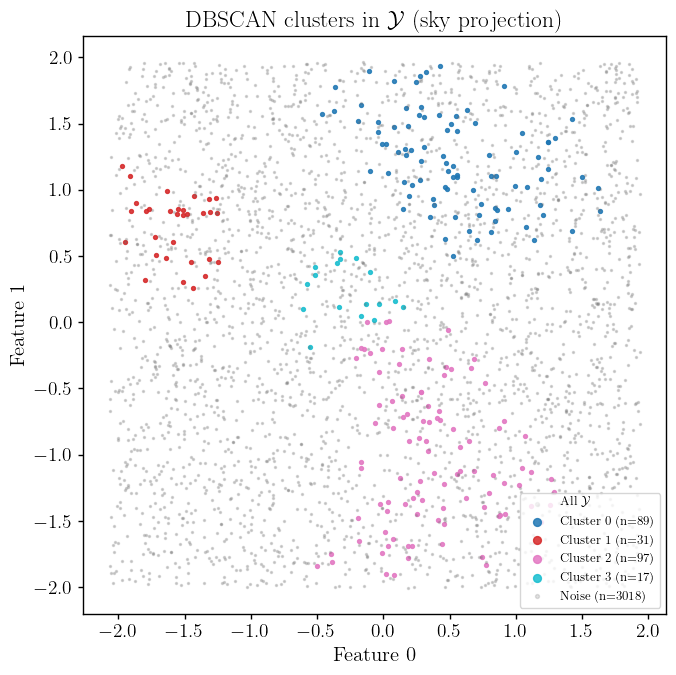

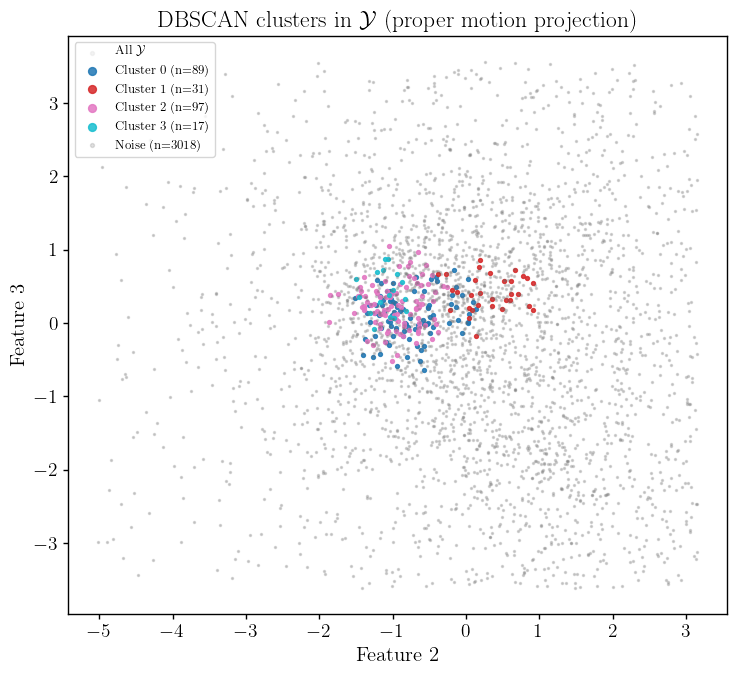

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN

def dbscan_cluster_and_plot(
    Y,
    cols=(0, 1),                 # which 2 dims to plot (e.g. (0,1) sky-like; (2,3) PM-like)
    eps=0.5,
    min_samples=10,
    metric="euclidean",
    figsize=(8, 7),
    s_bg=2,
    s_cl=8,
    alpha_bg=0.25,
    alpha_cl=0.85,
    title=None,
    rasterized=True,
):
    """
    Run DBSCAN on full Y (optionally in >2 dims), then plot clusters on top of all Y.

    Notes
    -----
    - DBSCAN labels: -1 is noise; 0..K-1 are clusters.
    - This runs clustering in the FULL feature space given by `cols_for_fit`.
      By default we fit in all dims of Y (recommended) and *plot* in cols=(0,1) or (2,3).
    """
    Y = np.asarray(Y, float)

    # Fit in the full feature space (all columns)
    Xfit = Y

    db = DBSCAN(eps=eps, min_samples=min_samples, metric=metric, n_jobs=-1)
    labels = db.fit_predict(Xfit)

    # Plot
    if title is None:
        title = rf"DBSCAN on $\mathcal{{Y}}$ (eps={eps}, min_samples={min_samples})"

    xcol, ycol = cols
    x = Y[:, xcol]
    y = Y[:, ycol]

    plt.figure(figsize=figsize)

    # Background: all points
    plt.scatter(x, y, s=s_bg, alpha=alpha_bg, color="lightgray", rasterized=rasterized, label="All $\\mathcal{Y}$")

    # Overlay clusters (exclude noise)
    uniq = sorted([u for u in np.unique(labels) if u != -1])
    cmap = plt.get_cmap("tab10", max(1, len(uniq)))

    for k, lab in enumerate(uniq):
        m = labels == lab
        plt.scatter(x[m], y[m], s=s_cl, alpha=alpha_cl, color=cmap(k),
                    rasterized=rasterized, label=rf"Cluster {lab} (n={m.sum()})")

    # Optional: show noise in darker gray (still subtle)
    noise = labels == -1
    if np.any(noise):
        plt.scatter(x[noise], y[noise], s=s_bg, alpha=0.20, color="dimgray",
                    rasterized=rasterized, label=rf"Noise (n={noise.sum()})")

    plt.xlabel(f"Feature {xcol}")
    plt.ylabel(f"Feature {ycol}")
    plt.title(title)
    plt.legend(markerscale=2, fontsize=9, frameon=True)
    plt.gca().set_aspect("equal", adjustable="box")
    plt.tight_layout()
    plt.show()

    # Return labels so you can inspect cluster membership
    return labels


# -------------------------
# Example usage
# -------------------------
# Sky-like panel (if your Y[:,0],Y[:,1] are position features)
labels_sky = dbscan_cluster_and_plot(
    Y,
    cols=(0, 1),
    eps=0.6,           # tune this
    min_samples=20,    # tune this
    title=r"DBSCAN clusters in $\mathcal{Y}$ (sky projection)"
)

# Proper-motion-like panel
labels_pm = dbscan_cluster_and_plot(
    Y,
    cols=(2, 3), 
    eps=0.6,
    min_samples=20,
    title=r"DBSCAN clusters in $\mathcal{Y}$ (proper motion projection)"
)

In [20]:
import numpy as np
import pandas as pd

# ---------- show full candidate table (no "***") ----------
pd.set_option("display.max_rows", 200)
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 0)
pd.set_option("display.max_colwidth", None)

# ---------- load candidates ----------
candi_wavelet = pd.read_csv("candidate_1.csv")

# rename if needed (edit these to match your file)
rename_map = {
    "ra": "ra_deg",
    "dec": "dec_deg",
    "pmra": "pmra",
    "pmdec": "pmdec",
}
candi_wavelet = candi_wavelet.rename(columns=rename_map)

# ---------- 1) pick your detections ----------

Y_det = Y[pass_thr]               # (n_det, 4)  SCALED features
Gamma_det = Gamma_i[pass_thr]

# ---------- 2) invert robust scaling ----------
med = np.asarray(scale["med"], dtype=float)   # shape (4,)
mad = np.asarray(scale["mad"], dtype=float)   # shape (4,)

# Y_raw columns are exactly: [dra*cos(dec0), ddec, pmra, pmdec] in ORIGINAL UNITS
Y_raw = Y_det * mad + med

dra_cosdec0 = Y_raw[:, 0]   # degrees (because your dra is computed in deg and then scaled)
ddec        = Y_raw[:, 1]   # degrees
pmra_raw    = Y_raw[:, 2]   # mas/yr
pmdec_raw   = Y_raw[:, 3]   # mas/yr

# ---------- 3) convert offsets -> RA/Dec using your chosen center ----------
ra0_deg  = float(center_ra)
dec0_deg = float(center_dec)
cos_dec0 = np.cos(np.deg2rad(dec0_deg))

dra_deg = dra_cosdec0 / cos_dec0
ra_deg  = (ra0_deg + dra_deg) % 360.0
dec_deg = dec0_deg + ddec

# ---------- 4) build detection table ----------
mine = pd.DataFrame({
    "source": "mine",
    "ra_deg": ra_deg,
    "dec_deg": dec_deg,
    "pmra": pmra_raw,
    "pmdec": pmdec_raw,
    "Gamma": Gamma_det
})

# ---------- 5) build candidate table in same schema ----------
cand = candi_wavelet.copy()

# ensure required columns exist
need = ["ra_deg", "dec_deg", "pmra", "pmdec"]
missing = [c for c in need if c not in cand.columns]
if missing:
    raise ValueError(f"candidate_1.csv is missing columns: {missing}. "
                     f"Available columns: {list(cand.columns)}")

cand = cand[need].copy()
cand.insert(0, "source", "candidate")
cand["Gamma"] = np.nan

# ---------- 6) combine + tidy ----------
combined = pd.concat([mine, cand], ignore_index=True)

# nice rounding for display
for col in ["ra_deg", "dec_deg", "pmra", "pmdec"]:
    combined[col] = combined[col].astype(float).round(8)
combined["Gamma"] = combined["Gamma"].round(3)

# sort by RA/Dec (or whatever you prefer)
combined = combined.sort_values(["source", "ra_deg", "dec_deg"]).reset_index(drop=True)

combined

,source,ra_deg,dec_deg,pmra,pmdec,Gamma
0,candidate,76.101291,-15.273487,0.124189,0.256543,NaN
1,candidate,76.105521,-15.378200,-0.091378,0.399323,NaN
2,candidate,76.123324,-15.377988,-0.298014,0.686010,NaN
3,candidate,76.135228,-15.271566,0.139491,0.246360,NaN
4,candidate,76.142538,-15.315390,0.390875,0.036680,NaN
5,candidate,76.143467,-15.355357,-0.109813,-0.288097,NaN
6,candidate,76.147012,-15.242290,0.099823,0.333504,NaN
7,candidate,76.149635,-15.288533,0.042995,1.036200,NaN
8,candidate,76.158490,-15.366224,0.305989,0.463938,NaN
9,candidate,76.179535,-15.181419,-0.245193,0.164555,NaN


In [23]:
import numpy as np
import pandas as pd
from sklearn.neighbors import KDTree

cand1 = pd.read_csv("candidate_1.csv")  # has ra_cand/dec_cand, pmra_cand/pmdec_cand (DR2)

# KDTree on DR3 query results
r_ra  = np.asarray(r["ra"], float)
r_dec = np.asarray(r["dec"], float)
tree = KDTree(np.column_stack([r_ra, r_dec]))

cand_ra  = cand1["ra"].to_numpy(float)
cand_dec = cand1["dec"].to_numpy(float)

dist, idx = tree.query(np.column_stack([cand_ra, cand_dec]), k=1)
dist = dist.flatten()
idx = idx.flatten()

# tolerance: 1e-4 deg ~ 0.36 arcsec
tol = 1e-4
matched = dist < tol

print("Matched candidates by sky:", matched.sum(), "/", len(cand1))
print("Worst sep (arcsec) among matched:", (dist[matched].max() * 3600) if matched.any() else None)

# Attach DR3 values for matched stars
cand1["ra_dr3"]   = np.nan
cand1["dec_dr3"]  = np.nan
cand1["pmra_dr3"] = np.nan
cand1["pmdec_dr3"]= np.nan

cand1.loc[matched, "ra_dr3"]   = r_ra[idx[matched]]
cand1.loc[matched, "dec_dr3"]  = r_dec[idx[matched]]
cand1.loc[matched, "pmra_dr3"] = np.asarray(r["pmra"][idx[matched]], float)
cand1.loc[matched, "pmdec_dr3"]= np.asarray(r["pmdec"][idx[matched]], float)

Matched candidates by sky: 16 / 17
Worst sep (arcsec) among matched: 0.0012963235447066704


### Combine IDE